In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
credit_df = pd.read_csv("../data/credit card fraud dataset.csv")
financial_df = pd.read_csv("../data/financial fraud detection dataset.csv")
fraud_df = pd.read_csv("../data/Fraud Detection dataset.csv")
synthetic_df = pd.read_csv("../data/synthetic fraud dataset.csv")

datasets = {
    "Credit Card Fraud": credit_df,
    "Financial Fraud": financial_df,
    "Fraud Detection / E-Commerce": fraud_df,
    "Synthetic Fraud": synthetic_df
}

In [3]:
for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())
    print()
    df.info()
    print()

Credit Card Fraud
Shape: (12072, 15)
Columns: ['transaction_id', 'transaction_date', 'customer_id', 'card_type', 'amount', 'merchant_category', 'merchant_country', 'transaction_channel', 'device_type', 'is_international', 'is_card_present', 'transactions_last_24h', 'average_amount_30d', 'risk_score', 'is_fraud']


,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,is_card_present,transactions_last_24h,average_amount_30d,risk_score,is_fraud
0,CC00011340,2025-07-15 19:54:24,C002995,visa,55.82,travel,UAE,website,windows,0.0,1.0,7.0,77.01,10.0,0
1,CC00007384,2025-07-08 14:57:48,C003084,mastercard,85.33,travel,UAE,atm,windows,0.0,0.0,3.0,134.09,35.0,0
2,CC00002213,2025-05-02 20:09:53,C003082,amex,76.06,entertainment,United States,website,other,1.0,1.0,5.0,162.75,28.0,0
3,CC00009658,2025-01-12 15:39:05,C002467,rupay,72.56,travel,United States,website,windows,0.0,0.0,4.0,104.91,33.0,0
4,CC00009328,2025-07-31 05:04:38,C001852,rupay,257.07,fuel,UAE,pos,android,1.0,0.0,1.0,179.18,53.0,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12072 entries, 0 to 12071
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         12072 non-null  object 
 1   transaction_date       12000 non-null  object 
 2   customer_id            12001 non-null  object 
 3   card_type              11994 non-null  object 
 4   amount                 11983 non-null  float64
 5   merchant_category      12007 non-null  object 
 6   merchant_country       11987 non-null  object 
 7   transaction_channel    11998 non-null  object 
 8   device_type            11992 non-null  object 
 9   is_international       11996 non-null  float64
 10  is_card_present        12012 non-null  float64
 11  transactions_last_24h  11995 non-null  float64
 12  average_amount_30d     11979 non-null  float64
 13  risk_score             11987 non-null  float64
 14  is_fraud               12072 non-null  int64  
dtypes

,transaction_id,transaction_date,sender_account_id,receiver_account_id,transaction_type,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,customer_age_group,customer_city,kyc_level,login_attempts,account_age_days,risk_score,is_fraud
0,FT00011571,2025-12-17 21:09:22,A0003951,A0005116,cash_in,95.05,28567.54,28472.49,272039.89,272134.94,60+,Kolkata,basic,1.0,1605.0,16.0,0
1,FT00007057,2025-05-18 10:38:28,A0000173,A0006969,debit,2941.78,232660.43,229718.65,735.03,3676.81,26-35,Bengaluru,basic,2.0,1273.0,7.0,0
2,FT00000058,2025-11-21 04:45:17,A0004037,A0008294,debit,85.76,125164.31,125078.55,222466.91,222552.67,26-35,Mumbai,standard,1.0,201.0,8.0,0
3,FT00014688,2025-12-06 09:42:47,A0002350,A0005894,debit,603.36,9435.17,8831.81,89411.21,90014.57,60+,Kolkata,basic,2.0,565.0,8.0,0
4,FT00007562,2025-07-27 09:57:40,A0004268,A0007835,cash_in,264.76,127940.35,127675.59,27787.44,28052.20,36-45,Kolkata,standard,2.0,164.0,9.0,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15090 entries, 0 to 15089
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           15090 non-null  object 
 1   transaction_date         14994 non-null  object 
 2   sender_account_id        14980 non-null  object 
 3   receiver_account_id      14996 non-null  object 
 4   transaction_type         15002 non-null  object 
 5   amount                   14985 non-null  float64
 6   sender_balance_before    14992 non-null  float64
 7   sender_balance_after     15013 non-null  float64
 8   receiver_balance_before  15000 non-null  float64
 9   receiver_balance_after   14995 non-null  float64
 10  customer_age_group       15003 non-null  object 
 11  customer_city            15012 non-null  object 
 12  kyc_level                14980 non-null  object 
 13  login_attempts           14997 non-null  float64
 14  account_age_days     

,order_id,order_date,customer_id,product_category,order_amount,payment_method,billing_country,shipping_country,email_age_days,account_age_days,device_type,ip_risk_level,failed_payment_attempts,delivery_speed,risk_score,is_fraud
0,ORD00003785,2025-09-15 10:42:46,EC000157,beauty,428.92,upi,Australia,NaN,1868.0,491.0,android,low,1.0,express,12.0,0
1,ORD00005829,2025-11-27 19:21:20,EC002940,fashion,1981.66,NaN,United Kingdom,United Kingdom,1041.0,1035.0,windows,low,0.0,same_day,6.0,0
2,ORD00007345,2025-08-01 10:08:16,EC002920,sports,849.85,upi,Singapore,Singapore,564.0,836.0,mac,low,0.0,standard,12.0,0
3,ORD00003114,2025-09-08 04:58:47,EC000941,electronics,100.96,net_banking,Singapore,Singapore,399.0,1782.0,windows,high,3.0,express,49.0,0
4,ORD00008267,2025-01-17 12:31:26,EC003901,sports,889.11,credit_card,India,India,400.0,1518.0,mac,medium,0.0,standard,18.0,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12072 entries, 0 to 12071
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 12072 non-null  object 
 1   order_date               12007 non-null  object 
 2   customer_id              12006 non-null  object 
 3   product_category         12004 non-null  object 
 4   order_amount             11995 non-null  object 
 5   payment_method           11994 non-null  object 
 6   billing_country          11994 non-null  object 
 7   shipping_country         11992 non-null  object 
 8   email_age_days           11973 non-null  float64
 9   account_age_days         12009 non-null  float64
 10  device_type              12009 non-null  object 
 11  ip_risk_level            12006 non-null  object 
 12  failed_payment_attempts  11995 non-null  float64
 13  delivery_speed           11989 non-null  object 
 14  risk_score           

,transaction_id,transaction_date,customer_id,transaction_type,amount,customer_balance,location,device_type,transaction_hour,distance_from_home_km,transactions_last_1h,new_device,new_location,risk_score,is_fraud
0,SF00018466,2025-12-05 05:38:28,SC003369,purchase,147.32,318381.96,Pune,windows,19.0,9.5,0.0,0.0,0.0,16.0,0
1,SF00013082,2025-02-25 18:25:30,SC004987,deposit,143.01,168333.70,Delhi,mac,10.0,5.4,1.0,0.0,0.0,12.0,0
2,SF00018209,2025-11-16 20:18:30,SC004589,bill_payment,26.06,16192.45,Indore,ios,9.0,16.9,0.0,0.0,0.0,13.0,0
3,SF00002362,2025-06-20 10:12:12,SC003444,deposit,1025.74,241065.38,Pune,other,9.0,12.7,5.0,0.0,0.0,30.0,0
4,SF00003315,2025-01-27 23:44:50,SC004037,deposit,912,2903.97,Kolkata,other,16.0,4.1,6.0,0.0,0.0,33.0,0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20120 entries, 0 to 20119
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         20120 non-null  object 
 1   transaction_date       19973 non-null  object 
 2   customer_id            19951 non-null  object 
 3   transaction_type       19978 non-null  object 
 4   amount                 19979 non-null  object 
 5   customer_balance       20000 non-null  float64
 6   location               19977 non-null  object 
 7   device_type            19978 non-null  object 
 8   transaction_hour       19982 non-null  float64
 9   distance_from_home_km  19987 non-null  float64
 10  transactions_last_1h   19983 non-null  float64
 11  new_device             19986 non-null  float64
 12  new_location           20001 non-null  float64
 13  risk_score             19982 non-null  float64
 14  is_fraud               20120 non-null  int64  
dtypes

In [4]:
for name, df in datasets.items():
    print("=" * 70, name)
    display(df.describe(include="all").T)

====================================================================== Credit Card Fraud


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,12072,12000,CC00001841,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,12000,11875,not_available,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,12001,3394,C002942,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
card_type,11994,4,mastercard,3040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,11983.0,NaN,NaN,NaN,349.09031,3284.633742,-500.73,93.615,176.17,329.855,329137.72
merchant_category,12007,27,grocery,1371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_country,11987,23,United Kingdom,1550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_channel,11998,12,website,3002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,11992,15,other,2401,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_international,11996.0,NaN,NaN,NaN,0.12004,0.325022,0.0,0.0,0.0,0.0,1.0


====================================================================== Financial Fraud


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,15090,15000,FT00006534,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,14994,14825,not_available,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sender_account_id,14980,4739,A0001900,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
receiver_account_id,14996,4755,A0006233,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,15002,15,bill_payment,3052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,14985.0,NaN,NaN,NaN,1182.278462,8551.212735,-7549.68,226.73,493.85,1061.08,492322.12
sender_balance_before,14992.0,NaN,NaN,NaN,127342.919019,72425.362413,45.37,64478.5,127820.735,190867.12,264695.59
sender_balance_after,15013.0,NaN,NaN,NaN,126331.53719,72408.835059,6.44,63511.93,126816.68,189663.63,249980.99
receiver_balance_before,15000.0,NaN,NaN,NaN,150487.977293,86734.889585,30.38,75791.38,150206.15,225660.1425,299995.66
receiver_balance_after,14995.0,NaN,NaN,NaN,151395.375029,86737.309426,91.25,76690.22,151173.21,226420.78,321714.78


====================================================================== Fraud Detection / E-Commerce


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,12072,12000,ORD00001734,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,12007,11885,not_available,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,12006,3943,EC002712,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,12004,18,fashion,2068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_amount,11995,10931,50,145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,11994,15,credit_card,2412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_country,11994,22,United Kingdom,1570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_country,11992,23,United Kingdom,1594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email_age_days,11973.0,NaN,NaN,NaN,1087.612127,637.324189,0.0,538.0,1077.0,1648.0,2199.0
account_age_days,12009.0,NaN,NaN,NaN,898.054792,519.981247,0.0,447.0,899.0,1348.0,1799.0


====================================================================== Synthetic Fraud


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,20120,20000,SF00006143,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,19973,19742,not_available,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,19951,5779,SC005044,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_type,19978,15,deposit,4059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,19979,17281,10,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_balance,20000.0,NaN,NaN,NaN,175834.910006,101199.1681,13.29,88509.9675,177056.74,262709.4375,349957.55
location,19977,8,Chennai,2597,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,19978,15,windows,3994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_hour,19982.0,NaN,NaN,NaN,11.565559,6.918631,0.0,6.0,12.0,18.0,23.0
distance_from_home_km,19987.0,NaN,NaN,NaN,13.460464,17.646985,0.1,4.1,8.2,16.1,551.9


In [5]:
missing_summary = []
for name, df in datasets.items():
    for col in df.columns:
        missing_summary.append({
            "Dataset": name,
            "Column": col,
            "Missing Values": int(df[col].isna().sum()),
            "Missing (%)": round(df[col].isna().mean() * 100, 2)
        })

missing_summary_df = pd.DataFrame(missing_summary)
display(
    missing_summary_df[missing_summary_df["Missing Values"] > 0]
    .sort_values(["Dataset", "Missing Values"], ascending=[True, False])
)

,Dataset,Column,Missing Values,Missing (%)
12,Credit Card Fraud,average_amount_30d,93,0.77
4,Credit Card Fraud,amount,89,0.74
6,Credit Card Fraud,merchant_country,85,0.70
13,Credit Card Fraud,risk_score,85,0.70
8,Credit Card Fraud,device_type,80,0.66
3,Credit Card Fraud,card_type,78,0.65
11,Credit Card Fraud,transactions_last_24h,77,0.64
9,Credit Card Fraud,is_international,76,0.63
7,Credit Card Fraud,transaction_channel,74,0.61
1,Credit Card Fraud,transaction_date,72,0.60


In [6]:
duplicate_summary = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Duplicate Rows": [df.duplicated().sum() for df in datasets.values()]
})
display(duplicate_summary)

credit_df = credit_df.drop_duplicates().copy()
financial_df = financial_df.drop_duplicates().copy()
fraud_df = fraud_df.drop_duplicates().copy()
synthetic_df = synthetic_df.drop_duplicates().copy()

,Dataset,Duplicate Rows
0,Credit Card Fraud,72
1,Financial Fraud,90
2,Fraud Detection / E-Commerce,72
3,Synthetic Fraud,120


In [7]:
credit_df["transaction_date"] = pd.to_datetime(credit_df["transaction_date"], errors="coerce")
financial_df["transaction_date"] = pd.to_datetime(financial_df["transaction_date"], errors="coerce")
fraud_df["order_date"] = pd.to_datetime(fraud_df["order_date"], errors="coerce")
synthetic_df["transaction_date"] = pd.to_datetime(synthetic_df["transaction_date"], errors="coerce")

fraud_df["order_amount"] = pd.to_numeric(fraud_df["order_amount"], errors="coerce")
synthetic_df["amount"] = pd.to_numeric(synthetic_df["amount"], errors="coerce")

credit_df = credit_df.dropna(subset=["transaction_date", "transaction_id"]).copy()
financial_df = financial_df.dropna(subset=["transaction_date", "transaction_id"]).copy()
fraud_df = fraud_df.dropna(subset=["order_date", "order_id"]).copy()
synthetic_df = synthetic_df.dropna(subset=["transaction_date", "transaction_id"]).copy()

credit_df = credit_df.drop_duplicates(subset="transaction_id", keep="first").copy()
financial_df = financial_df.drop_duplicates(subset="transaction_id", keep="first").copy()
fraud_df = fraud_df.drop_duplicates(subset="order_id", keep="first").copy()
synthetic_df = synthetic_df.drop_duplicates(subset="transaction_id", keep="first").copy()

print("Date and amount columns converted successfully.")

Date and amount columns converted successfully.


In [8]:
for name, df in {
    "Credit Card Fraud": credit_df,
    "Financial Fraud": financial_df,
    "Fraud Detection / E-Commerce": fraud_df,
    "Synthetic Fraud": synthetic_df
}.items():
    print(name, ":", sorted(df["is_fraud"].dropna().unique()))

Credit Card Fraud : [np.int64(0), np.int64(1)]
Financial Fraud : [np.int64(0), np.int64(1)]
Fraud Detection / E-Commerce : [np.int64(0), np.int64(1)]
Synthetic Fraud : [np.int64(0), np.int64(1)]


In [9]:
for df_name, df in {
    "credit": credit_df,
    "financial": financial_df,
    "fraud": fraud_df,
    "synthetic": synthetic_df
}.items():
    invalid = df["is_fraud"].notna() & ~df["is_fraud"].isin([0, 1])
    if invalid.any():
        df.drop(index=df.index[invalid], inplace=True)

In [10]:
datasets = {
    "Credit Card Fraud": credit_df,
    "Financial Fraud": financial_df,
    "Fraud Detection / E-Commerce": fraud_df,
    "Synthetic Fraud": synthetic_df
}

for name, df in datasets.items():
    feature_cols = [c for c in df.columns if c != "is_fraud"]

    for col in df[feature_cols].select_dtypes(include=np.number).columns:
        if df[col].isna().any():
            median_value = df[col].median()
            df[col] = df[col].fillna(median_value)

    for col in df[feature_cols].select_dtypes(include=["object", "category"]).columns:
        if "id" not in col.lower():
            df[col] = df[col].astype("string").str.strip().str.lower()

        if df[col].isna().any():
            if "id" in col.lower():
                df[col] = df[col].fillna("Unknown")
            else:
                mode = df[col].mode(dropna=True)
                df[col] = df[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("Missing-value treatment completed for all four datasets.")

Missing-value treatment completed for all four datasets.


Credit Card Fraud: negative amounts = 0, min = 10.0, max = 329137.72


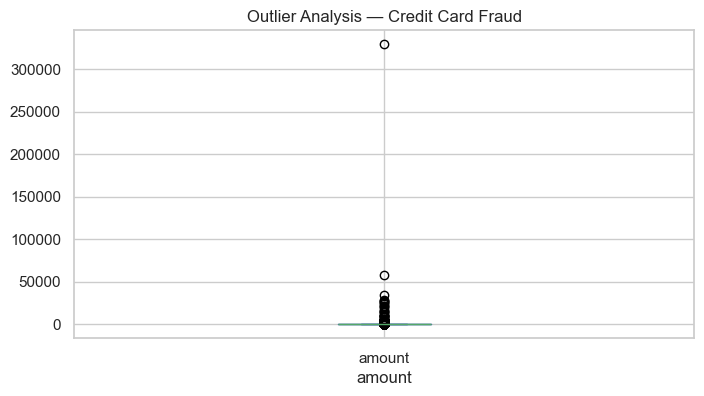

Financial Fraud: negative amounts = 0, min = 25.0, max = 492322.12


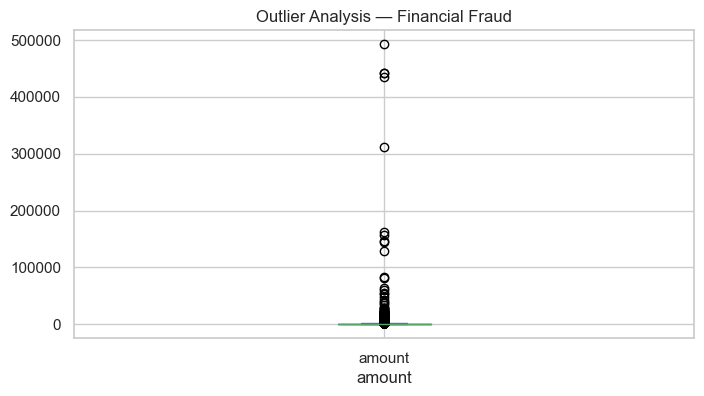

Fraud Detection / E-Commerce: negative amounts = 0, min = 50.0, max = 186564.22


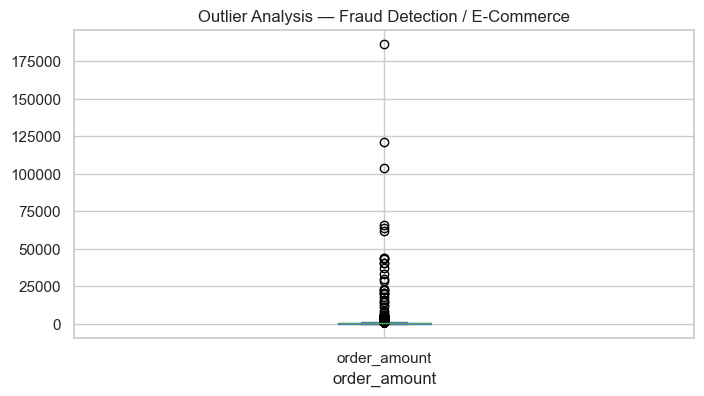

Synthetic Fraud: negative amounts = 0, min = 10.0, max = 245924.12


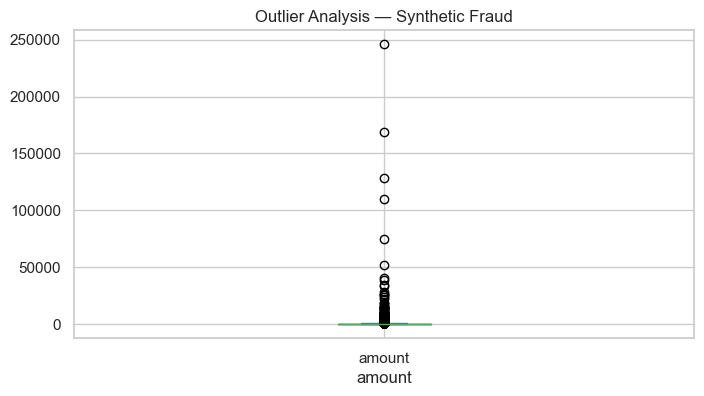

In [11]:
amount_columns = {
    "Credit Card Fraud": "amount",
    "Financial Fraud": "amount",
    "Fraud Detection / E-Commerce": "order_amount",
    "Synthetic Fraud": "amount"
}

for name, amount_col in amount_columns.items():
    df = datasets[name]
    # Negative transaction values are treated as invalid entries in these datasets.
    negative_index = df.index[df[amount_col] < 0]
    df.drop(index=negative_index, inplace=True)
    print(f"{name}: negative amounts = {(df[amount_col] < 0).sum()}, "
          f"min = {df[amount_col].min()}, max = {df[amount_col].max()}")

    plt.figure(figsize=(8, 4))
    df[[amount_col]].plot(kind="box", ax=plt.gca())
    plt.title(f"Outlier Analysis — {name}")
    plt.xlabel(amount_col)
    plt.show()

**Outlier treatment decision:** Extreme transaction values are identified but not automatically deleted because they may represent genuine fraudulent behavior.

In [12]:
credit_df["transaction_hour"] = credit_df["transaction_date"].dt.hour
credit_df["transaction_day"] = credit_df["transaction_date"].dt.day
credit_df["transaction_month"] = credit_df["transaction_date"].dt.month

financial_df["transaction_hour"] = financial_df["transaction_date"].dt.hour
financial_df["transaction_day"] = financial_df["transaction_date"].dt.day
financial_df["transaction_month"] = financial_df["transaction_date"].dt.month

fraud_df["transaction_hour"] = fraud_df["order_date"].dt.hour
fraud_df["transaction_day"] = fraud_df["order_date"].dt.day
fraud_df["transaction_month"] = fraud_df["order_date"].dt.month

synthetic_df["transaction_hour"] = synthetic_df["transaction_date"].dt.hour
synthetic_df["transaction_day"] = synthetic_df["transaction_date"].dt.day
synthetic_df["transaction_month"] = synthetic_df["transaction_date"].dt.month

datasets = {
    "Credit Card Fraud": credit_df,
    "Financial Fraud": financial_df,
    "Fraud Detection / E-Commerce": fraud_df,
    "Synthetic Fraud": synthetic_df
}

In [13]:
final_summary = []
for name, df in datasets.items():
    id_column = "order_id" if name == "Fraud Detection / E-Commerce" else "transaction_id"
    final_summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum()),
        "Duplicate IDs": int(df[id_column].duplicated().sum()),
        "Invalid Fraud Targets": int((~df["is_fraud"].isin([0, 1])).sum()),
        "Fraud Transactions": int(df["is_fraud"].sum()),
        "Fraud Rate (%)": round(df["is_fraud"].mean() * 100, 2)
    })

final_summary_df = pd.DataFrame(final_summary)
display(final_summary_df)

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Duplicate IDs,Invalid Fraud Targets,Fraud Transactions,Fraud Rate (%)
0,Credit Card Fraud,11726,18,0,0,0,0,122,1.04
1,Financial Fraud,14654,20,0,0,0,0,185,1.26
2,Fraud Detection / E-Commerce,11741,19,0,0,0,0,358,3.05
3,Synthetic Fraud,19540,17,0,0,0,0,333,1.70


In [14]:
new_cols = ["transaction_hour", "transaction_day", "transaction_month"]

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    display(df[new_cols + ["is_fraud"]].head(10))


Credit Card Fraud


,transaction_hour,transaction_day,transaction_month,is_fraud
0,19,15,7,0
1,14,8,7,0
2,20,2,5,0
3,15,12,1,0
4,5,31,7,0
5,8,17,11,0
6,18,15,1,0
7,7,25,3,0
8,23,14,1,0
9,18,23,5,0



Financial Fraud


,transaction_hour,transaction_day,transaction_month,is_fraud
0,21,17,12,0
1,10,18,5,0
2,4,21,11,0
3,9,6,12,0
4,9,27,7,0
5,17,18,7,0
6,8,2,7,0
7,4,29,3,0
8,22,21,5,0
9,11,16,8,0



Fraud Detection / E-Commerce


,transaction_hour,transaction_day,transaction_month,is_fraud
0,10,15,9,0
1,19,27,11,0
2,10,1,8,0
3,4,8,9,0
4,12,17,1,0
5,19,20,7,0
6,10,30,4,0
7,3,22,10,0
8,2,15,9,0
9,21,25,1,0



Synthetic Fraud


,transaction_hour,transaction_day,transaction_month,is_fraud
0,5,5,12,0
1,18,25,2,0
2,20,16,11,0
3,10,20,6,0
4,23,27,1,0
5,22,11,3,0
6,5,24,3,0
7,5,3,10,0
8,6,3,12,0
9,2,25,10,0


In [15]:
for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(f"FINAL CLEANED DATASET — {name}")
    print("=" * 70)
    display(df.head(10))


FINAL CLEANED DATASET — Credit Card Fraud


,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,is_card_present,transactions_last_24h,average_amount_30d,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month
0,CC00011340,2025-07-15 19:54:24,C002995,visa,55.82,travel,uae,website,windows,0.0,1.0,7.0,77.01,10.0,0,19,15,7
1,CC00007384,2025-07-08 14:57:48,C003084,mastercard,85.33,travel,uae,atm,windows,0.0,0.0,3.0,134.09,35.0,0,14,8,7
2,CC00002213,2025-05-02 20:09:53,C003082,amex,76.06,entertainment,united states,website,other,1.0,1.0,5.0,162.75,28.0,0,20,2,5
3,CC00009658,2025-01-12 15:39:05,C002467,rupay,72.56,travel,united states,website,windows,0.0,0.0,4.0,104.91,33.0,0,15,12,1
4,CC00009328,2025-07-31 05:04:38,C001852,rupay,257.07,fuel,uae,pos,android,1.0,0.0,1.0,179.18,53.0,0,5,31,7
5,CC00003925,2025-11-17 08:23:53,C001215,visa,414.34,fashion,canada,atm,android,0.0,0.0,8.0,71.05,25.0,0,8,17,11
6,CC00000977,2025-01-15 18:10:37,C002975,amex,251.15,fuel,united kingdom,website,mac,0.0,1.0,2.0,78.79,11.0,0,18,15,1
7,CC00010094,2025-03-25 07:50:12,C003057,amex,387.46,electronics,canada,pos,android,0.0,0.0,6.0,124.99,21.0,0,7,25,3
8,CC00008129,2025-01-14 23:36:46,C002451,amex,97.66,entertainment,australia,atm,android,0.0,1.0,2.0,279.06,15.0,0,23,14,1
9,CC00005321,2025-05-23 18:18:19,C002272,rupay,163.09,grocery,uae,website,windows,0.0,1.0,1.0,71.28,18.0,0,18,23,5



FINAL CLEANED DATASET — Financial Fraud


,transaction_id,transaction_date,sender_account_id,receiver_account_id,transaction_type,amount,sender_balance_before,sender_balance_after,receiver_balance_before,receiver_balance_after,customer_age_group,customer_city,kyc_level,login_attempts,account_age_days,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month
0,FT00011571,2025-12-17 21:09:22,A0003951,A0005116,cash_in,95.05,28567.54,28472.49,272039.89,272134.94,60+,kolkata,basic,1.0,1605.0,16.0,0,21,17,12
1,FT00007057,2025-05-18 10:38:28,A0000173,A0006969,debit,2941.78,232660.43,229718.65,735.03,3676.81,26-35,bengaluru,basic,2.0,1273.0,7.0,0,10,18,5
2,FT00000058,2025-11-21 04:45:17,A0004037,A0008294,debit,85.76,125164.31,125078.55,222466.91,222552.67,26-35,mumbai,standard,1.0,201.0,8.0,0,4,21,11
3,FT00014688,2025-12-06 09:42:47,A0002350,A0005894,debit,603.36,9435.17,8831.81,89411.21,90014.57,60+,kolkata,basic,2.0,565.0,8.0,0,9,6,12
4,FT00007562,2025-07-27 09:57:40,A0004268,A0007835,cash_in,264.76,127940.35,127675.59,27787.44,28052.20,36-45,kolkata,standard,2.0,164.0,9.0,0,9,27,7
5,FT00014990,2025-07-18 17:06:28,A0004178,A0007525,debit,499.11,170144.57,169645.46,210073.37,210572.48,26-35,indore,enhanced,2.0,868.0,16.0,0,17,18,7
6,FT00006782,2025-07-02 08:14:49,A0003983,A0006342,bill_payment,242.84,100177.34,99934.50,32996.98,33239.82,26-35,indore,basic,3.0,545.0,12.0,0,8,2,7
7,FT00008052,2025-03-29 04:11:53,A0002751,A0008605,bill_payment,329.12,231452.43,231123.31,108311.67,108640.79,18-25,pune,standard,1.0,441.0,13.0,0,4,29,3
8,FT00000201,2025-05-21 22:11:42,A0002100,A0007875,transfer,250.54,11416.28,11165.74,245504.25,245754.79,60+,kolkata,standard,2.0,651.0,25.0,0,22,21,5
9,FT00010157,2025-08-16 11:19:07,A0003944,A0008836,transfer,316.05,198178.07,197862.02,100071.24,100387.29,18-25,delhi,basic,1.0,1161.0,24.0,0,11,16,8



FINAL CLEANED DATASET — Fraud Detection / E-Commerce


,order_id,order_date,customer_id,product_category,order_amount,payment_method,billing_country,shipping_country,email_age_days,account_age_days,device_type,ip_risk_level,failed_payment_attempts,delivery_speed,risk_score,is_fraud,transaction_hour,transaction_day,transaction_month
0,ORD00003785,2025-09-15 10:42:46,EC000157,beauty,428.92,upi,australia,united kingdom,1868.0,491.0,android,low,1.0,express,12.0,0,10,15,9
1,ORD00005829,2025-11-27 19:21:20,EC002940,fashion,1981.66,credit_card,united kingdom,united kingdom,1041.0,1035.0,windows,low,0.0,same_day,6.0,0,19,27,11
2,ORD00007345,2025-08-01 10:08:16,EC002920,sports,849.85,upi,singapore,singapore,564.0,836.0,mac,low,0.0,standard,12.0,0,10,1,8
3,ORD00003114,2025-09-08 04:58:47,EC000941,electronics,100.96,net_banking,singapore,singapore,399.0,1782.0,windows,high,3.0,express,49.0,0,4,8,9
4,ORD00008267,2025-01-17 12:31:26,EC003901,sports,889.11,credit_card,india,india,400.0,1518.0,mac,medium,0.0,standard,18.0,0,12,17,1
5,ORD00010314,2025-07-20 19:21:08,EC001505,home,575.68,credit_card,australia,germany,877.0,1251.0,other,medium,3.0,standard,55.0,0,19,20,7
6,ORD00008546,2025-04-30 10:48:21,EC003022,electronics,259.31,credit_card,singapore,singapore,336.0,486.0,other,medium,0.0,standard,21.0,0,10,30,4
7,ORD00005976,2025-10-22 03:03:39,EC002963,sports,465.21,debit_card,canada,canada,722.0,1777.0,android,high,3.0,standard,52.0,0,3,22,10
8,ORD00009625,2025-09-15 02:59:39,EC002101,electronics,427.24,wallet,uae,uae,1076.0,128.0,mac,low,2.0,same_day,24.0,0,2,15,9
9,ORD00009451,2025-01-25 21:36:49,EC001754,books,335.70,upi,germany,germany,783.0,78.0,ios,low,0.0,standard,8.0,0,21,25,1



FINAL CLEANED DATASET — Synthetic Fraud


,transaction_id,transaction_date,customer_id,transaction_type,amount,customer_balance,location,device_type,transaction_hour,distance_from_home_km,transactions_last_1h,new_device,new_location,risk_score,is_fraud,transaction_day,transaction_month
0,SF00018466,2025-12-05 05:38:28,SC003369,purchase,147.32,318381.96,pune,windows,5,9.5,0.0,0.0,0.0,16.0,0,5,12
1,SF00013082,2025-02-25 18:25:30,SC004987,deposit,143.01,168333.70,delhi,mac,18,5.4,1.0,0.0,0.0,12.0,0,25,2
2,SF00018209,2025-11-16 20:18:30,SC004589,bill_payment,26.06,16192.45,indore,ios,20,16.9,0.0,0.0,0.0,13.0,0,16,11
3,SF00002362,2025-06-20 10:12:12,SC003444,deposit,1025.74,241065.38,pune,other,10,12.7,5.0,0.0,0.0,30.0,0,20,6
4,SF00003315,2025-01-27 23:44:50,SC004037,deposit,912.00,2903.97,kolkata,other,23,4.1,6.0,0.0,0.0,33.0,0,27,1
5,SF00012234,2025-03-11 22:04:24,SC001186,deposit,382.21,169372.51,pune,mac,22,11.2,5.0,0.0,0.0,23.0,0,11,3
6,SF00016713,2025-03-24 05:39:38,SC005059,deposit,456.38,126883.37,delhi,ios,5,2.8,1.0,0.0,0.0,13.0,0,24,3
7,SF00017172,2025-10-03 05:41:53,SC001593,deposit,32.66,246337.34,chennai,android,5,1.9,2.0,0.0,0.0,19.0,0,3,10
8,SF00006490,2025-12-03 06:59:21,SC002631,transfer,160.12,89603.01,kolkata,mac,6,3.5,5.0,0.0,0.0,28.0,0,3,12
9,SF00013128,2025-10-25 02:30:47,SC005273,deposit,2247.90,145579.47,kolkata,android,2,55.7,6.0,1.0,1.0,62.0,0,25,10


In [16]:
credit_df.to_csv("credit_card_fraud_cleaned.csv", index=False)
financial_df.to_csv("financial_fraud_cleaned.csv", index=False)
fraud_df.to_csv("fraud_detection_cleaned.csv", index=False)
synthetic_df.to_csv("synthetic_fraud_cleaned.csv", index=False)

print("All four cleaned datasets saved successfully.")

All four cleaned datasets saved successfully.


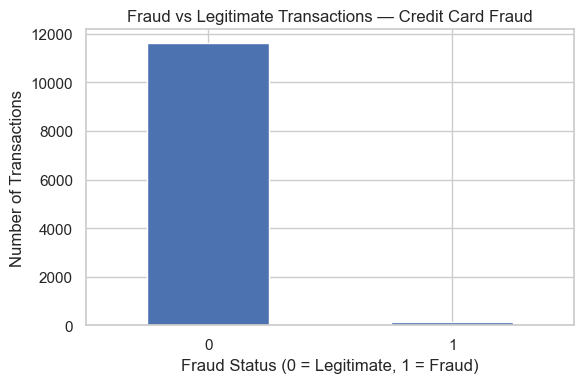

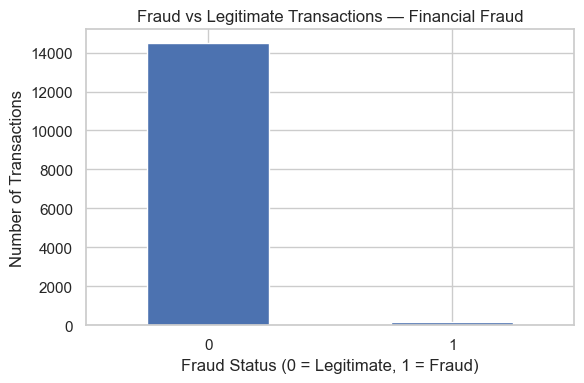

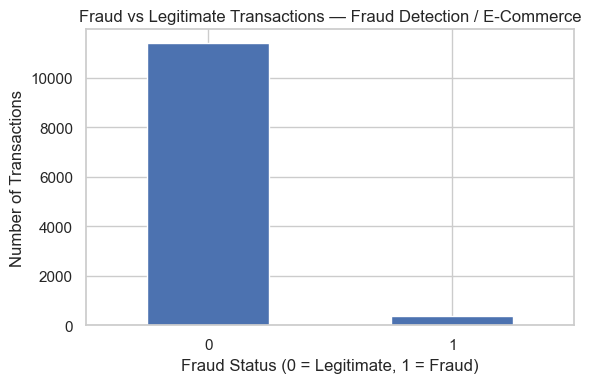

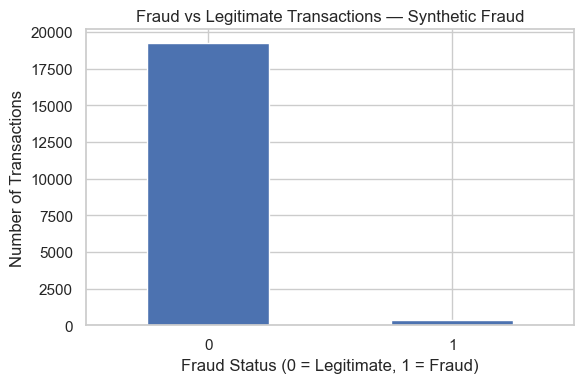

In [17]:
for name, df in datasets.items():
    plt.figure(figsize=(6, 4))
    df["is_fraud"].value_counts().sort_index().plot(kind="bar")
    plt.title(f"Fraud vs Legitimate Transactions — {name}")
    plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
    plt.ylabel("Number of Transactions")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [18]:
fraud_distribution = []
for name, df in datasets.items():
    counts = df["is_fraud"].value_counts()
    fraud_distribution.append({
        "Dataset": name,
        "Legitimate (%)": round(counts.get(0, 0) / len(df) * 100, 2),
        "Fraud (%)": round(counts.get(1, 0) / len(df) * 100, 2)
    })

display(pd.DataFrame(fraud_distribution))

,Dataset,Legitimate (%),Fraud (%)
0,Credit Card Fraud,98.96,1.04
1,Financial Fraud,98.74,1.26
2,Fraud Detection / E-Commerce,96.95,3.05
3,Synthetic Fraud,98.30,1.70


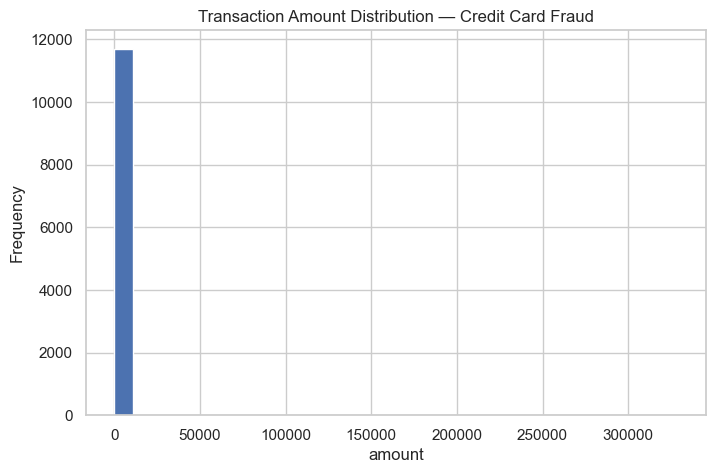

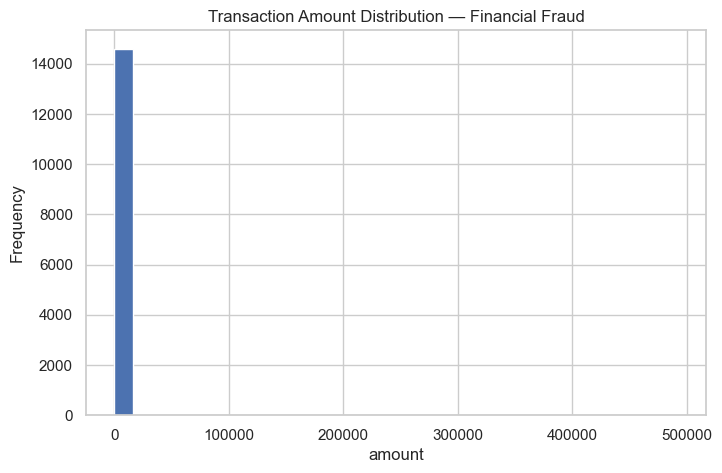

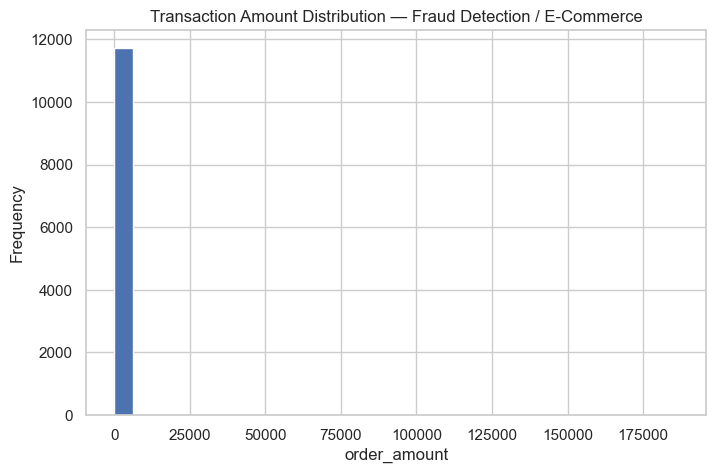

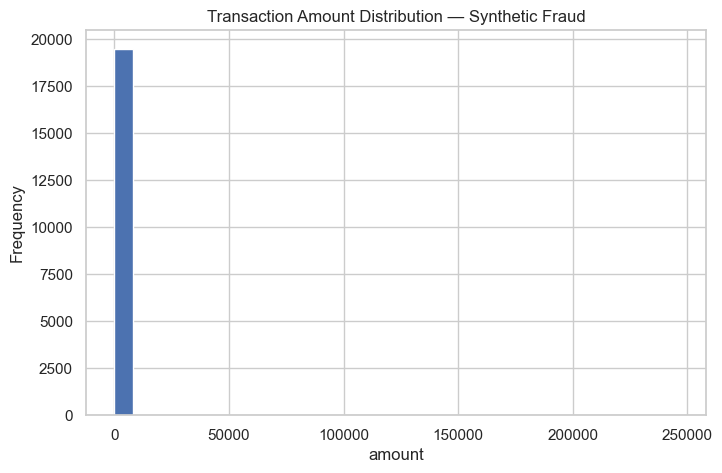

In [19]:
for name, amount_col in amount_columns.items():
    df = datasets[name]
    plt.figure(figsize=(8, 5))
    df[amount_col].plot(kind="hist", bins=30, ax=plt.gca())
    plt.title(f"Transaction Amount Distribution — {name}")
    plt.xlabel(amount_col)
    plt.ylabel("Frequency")
    plt.show()

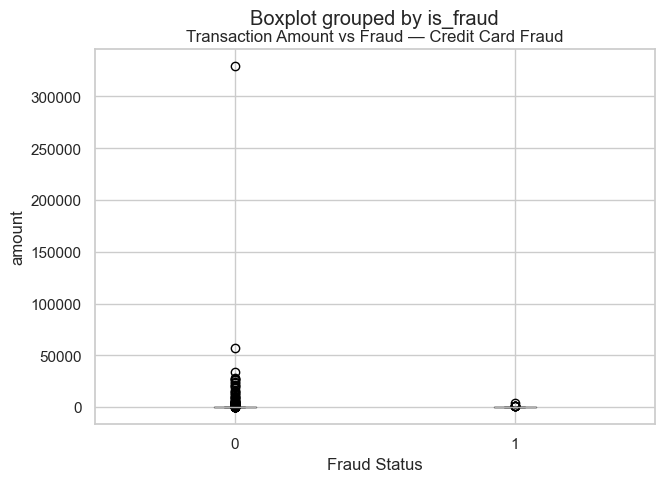

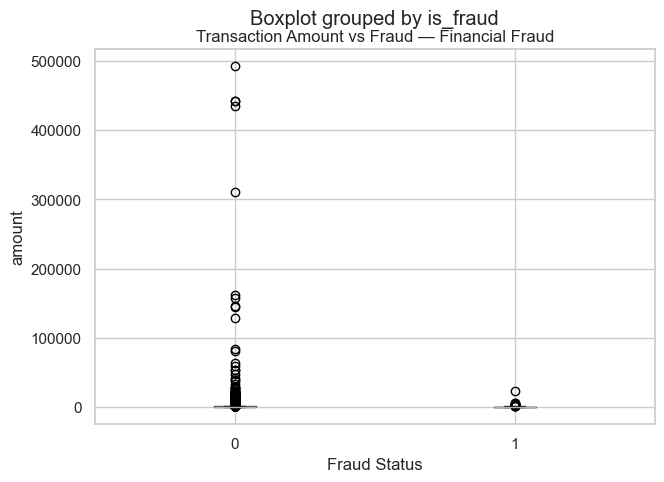

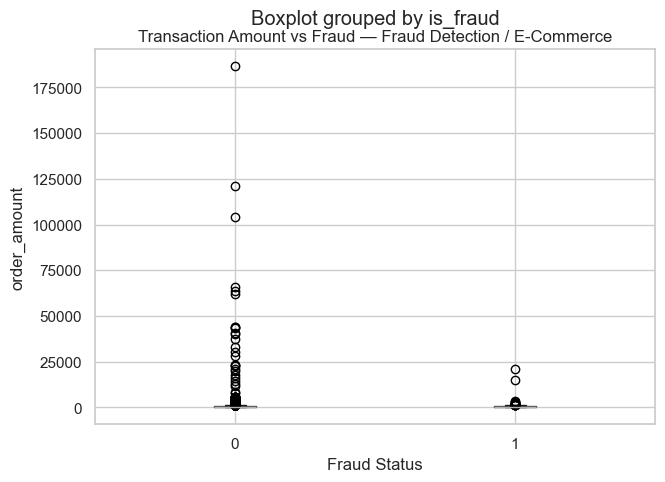

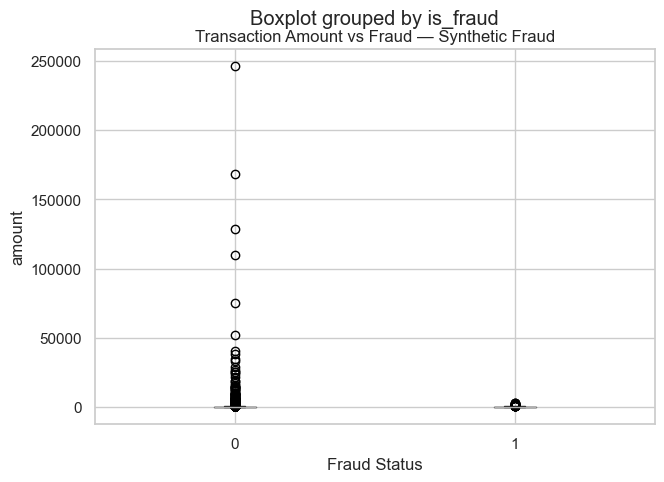

In [20]:
for name, amount_col in amount_columns.items():
    df = datasets[name]
    plt.figure(figsize=(7, 5))
    df.boxplot(column=amount_col, by="is_fraud", ax=plt.gca())
    plt.title(f"Transaction Amount vs Fraud — {name}")
    plt.xlabel("Fraud Status")
    plt.ylabel(amount_col)
    plt.show()

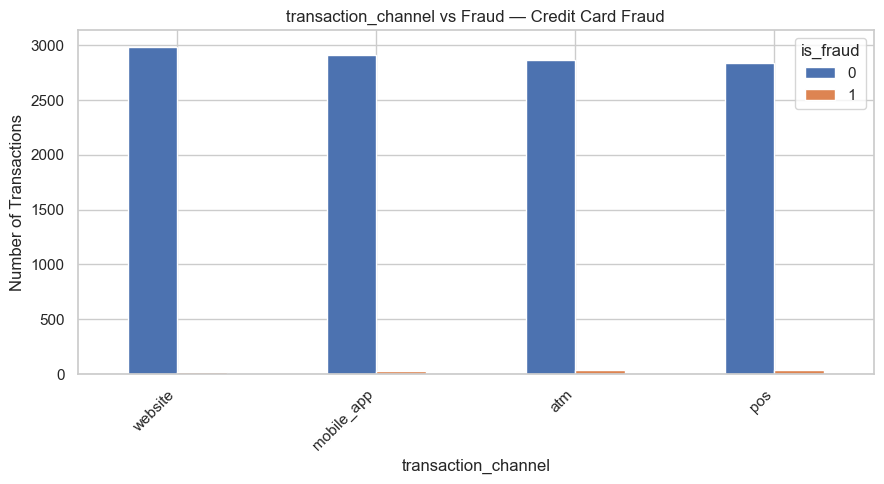

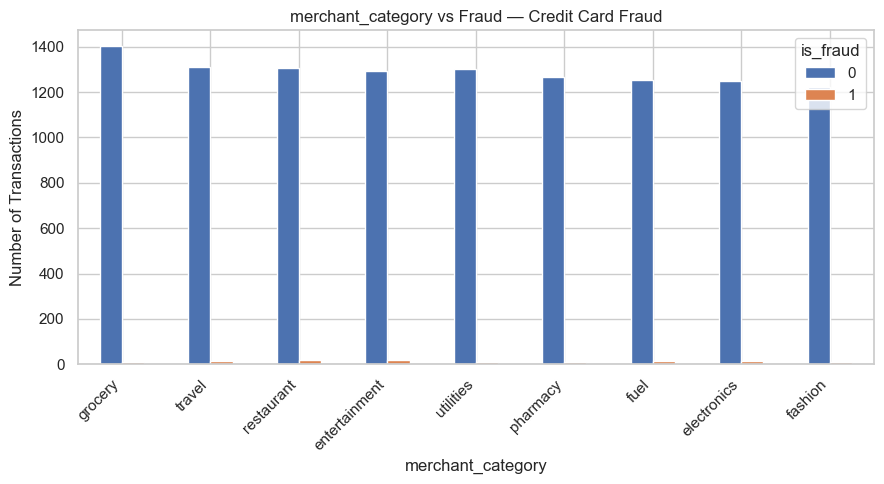

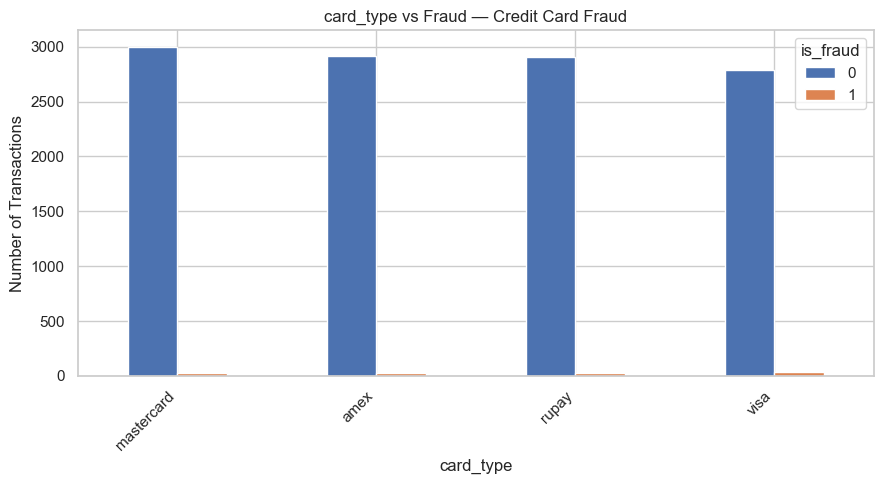

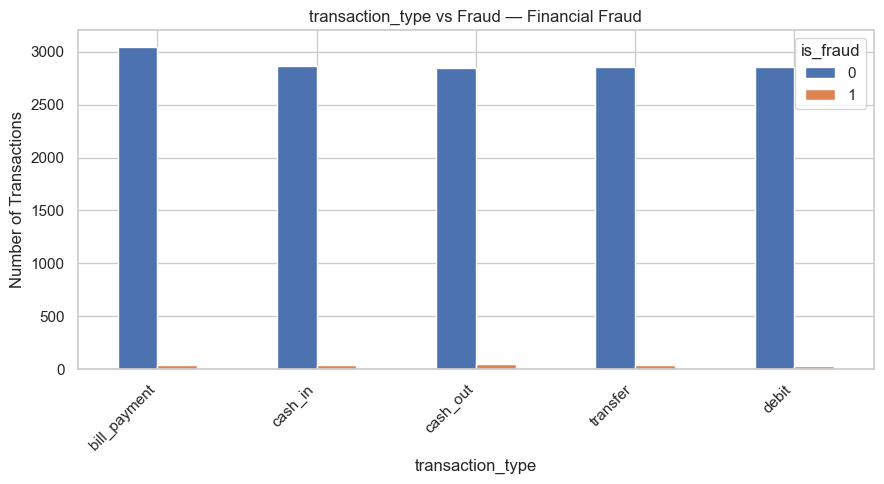

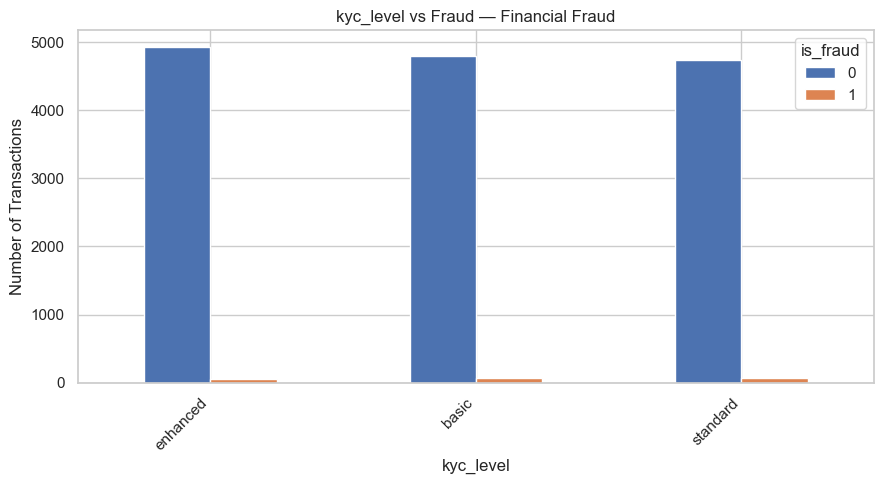

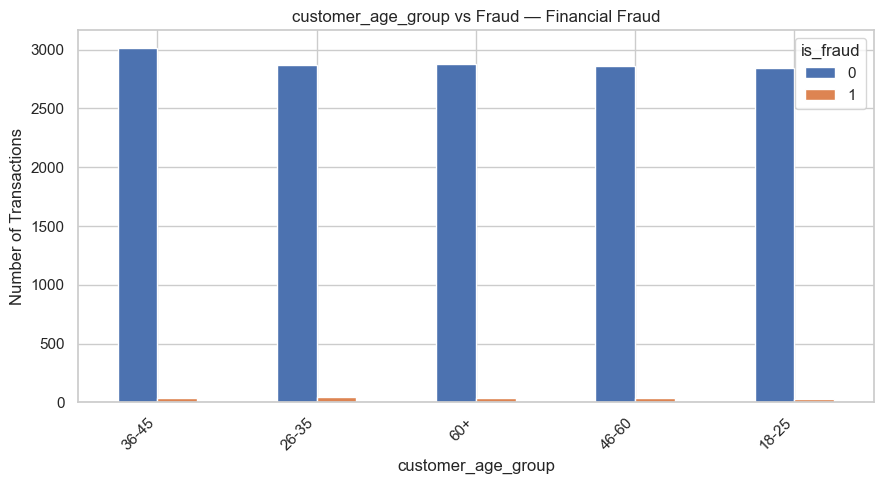

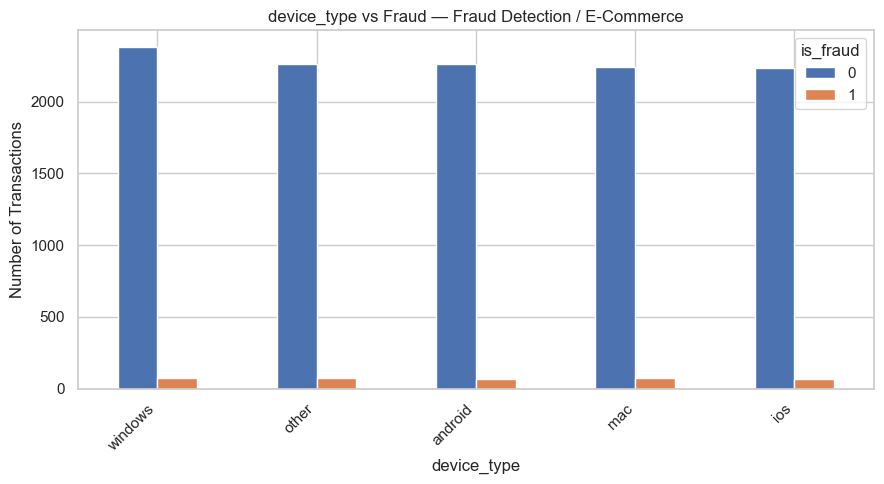

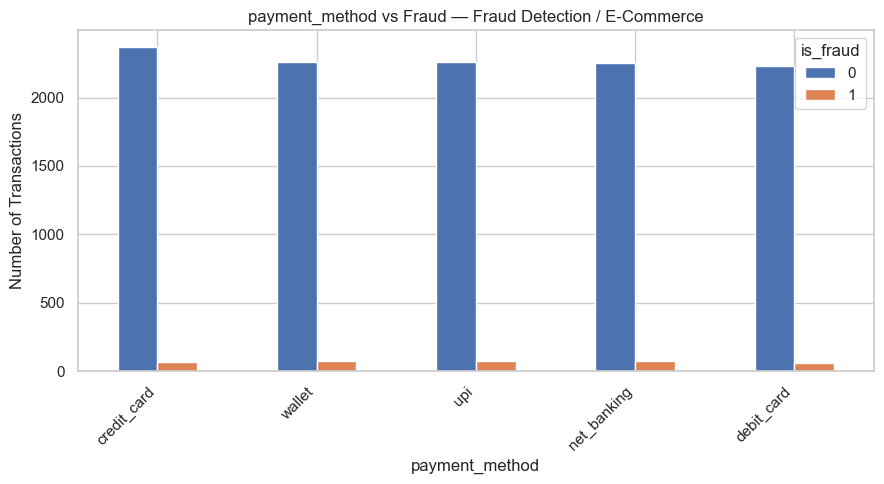

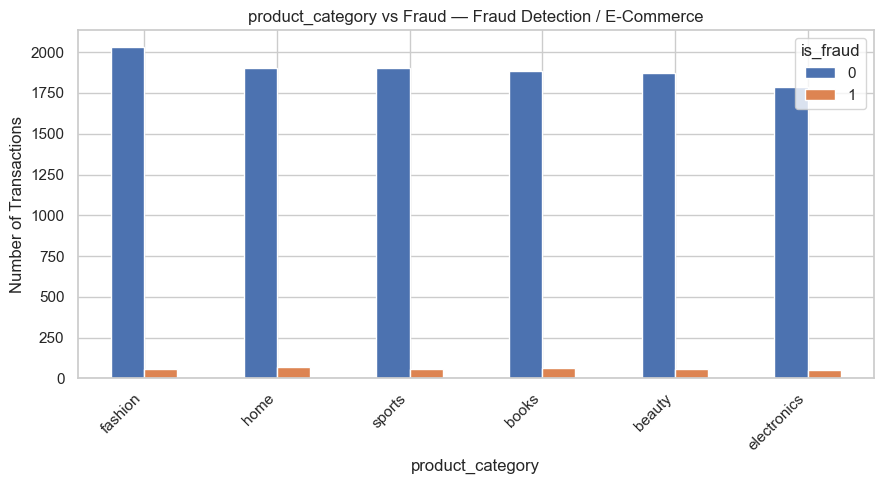

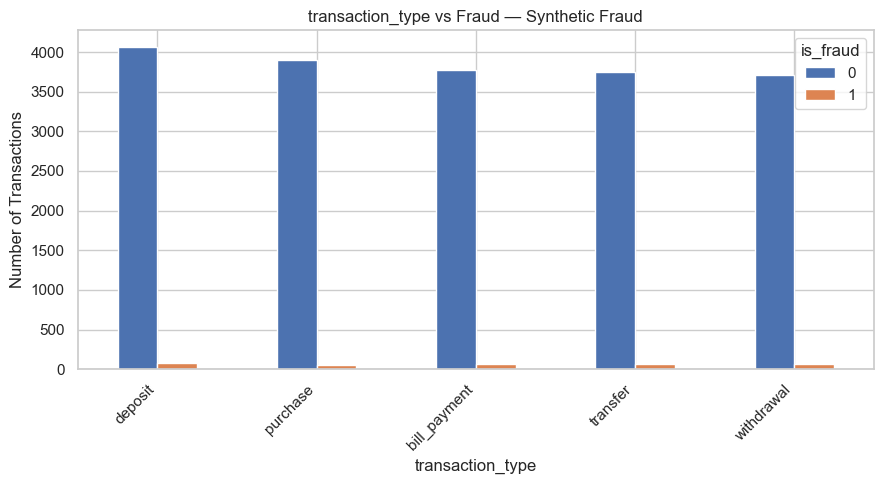

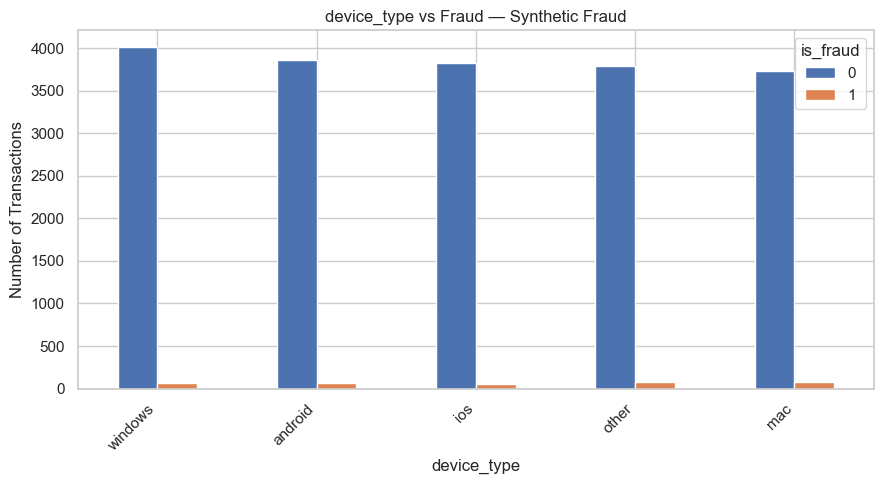

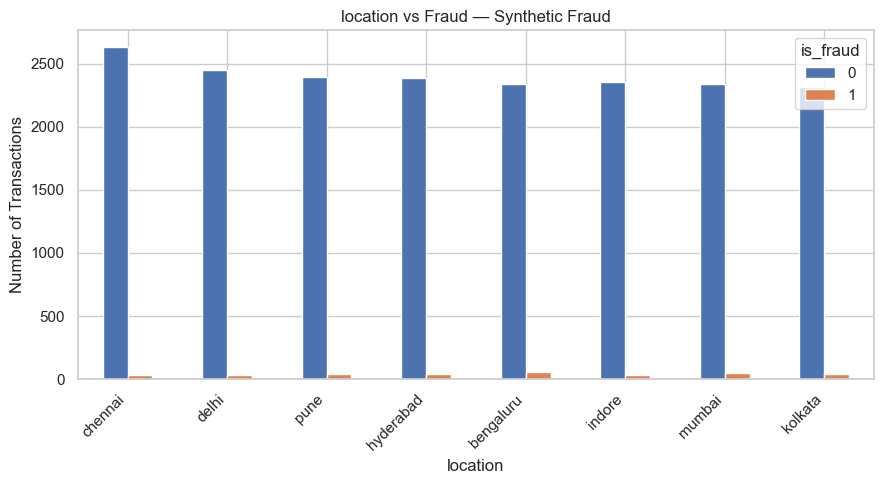

In [21]:
preferred_categoricals = [
    "transaction_type", "transaction_channel", "merchant_category",
    "card_type", "merchant_country", "device_type", "payment_method",
    "product_category", "billing_country", "shipping_country",
    "ip_risk_level", "delivery_speed", "location", "kyc_level",
    "customer_age_group"
]

for name, df in datasets.items():
    available = [c for c in preferred_categoricals if c in df.columns][:3]

    for col in available:
        top_values = df[col].value_counts().head(10).index
        plot_df = df[df[col].isin(top_values)]

        counts = pd.crosstab(plot_df[col], plot_df["is_fraud"]).reindex(top_values, fill_value=0)
        counts.plot(kind="bar", figsize=(9, 5))
        plt.title(f"{col} vs Fraud — {name}")
        plt.xlabel(col)
        plt.ylabel("Number of Transactions")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

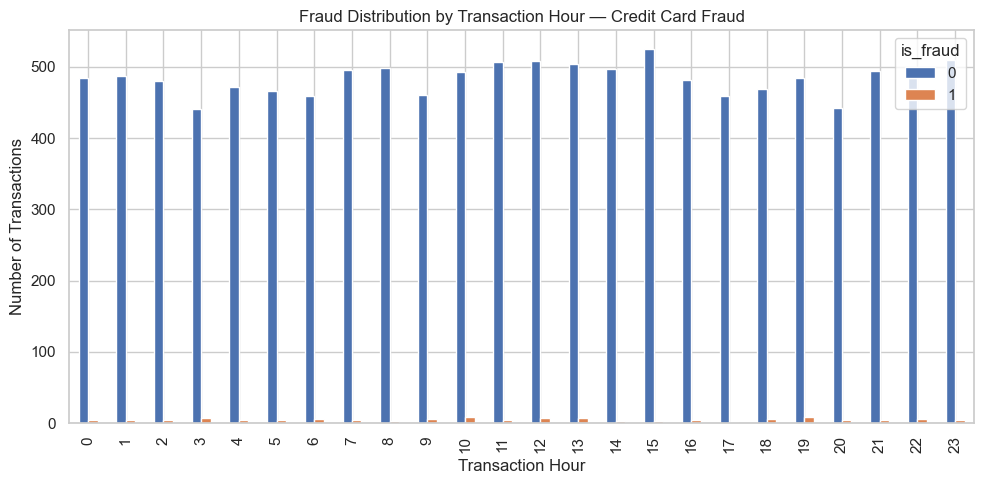

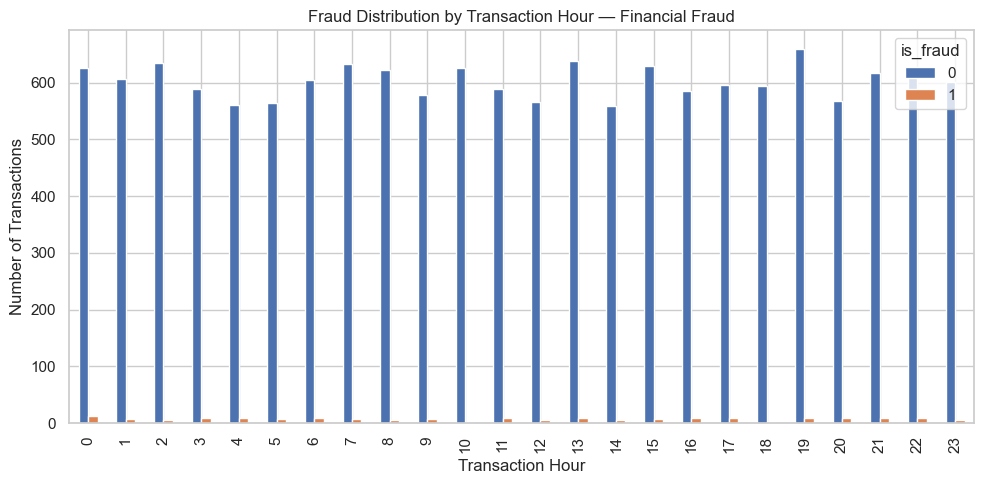

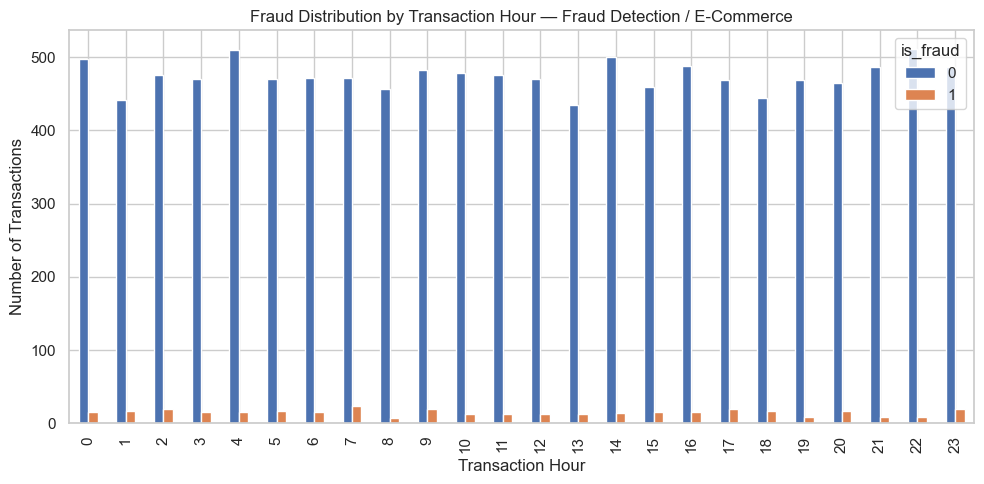

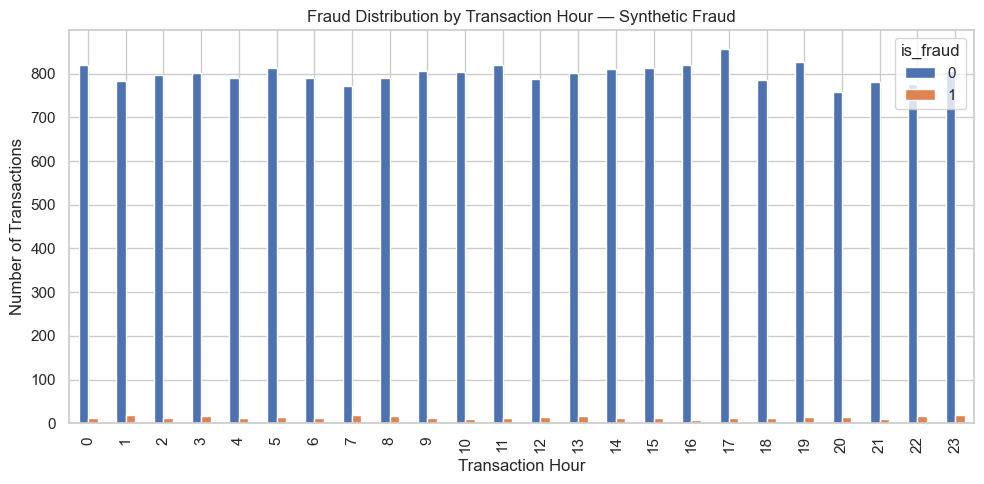

In [22]:
for name, df in datasets.items():
    pd.crosstab(df["transaction_hour"], df["is_fraud"]).plot(kind="bar", figsize=(10, 5))
    plt.title(f"Fraud Distribution by Transaction Hour — {name}")
    plt.xlabel("Transaction Hour")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

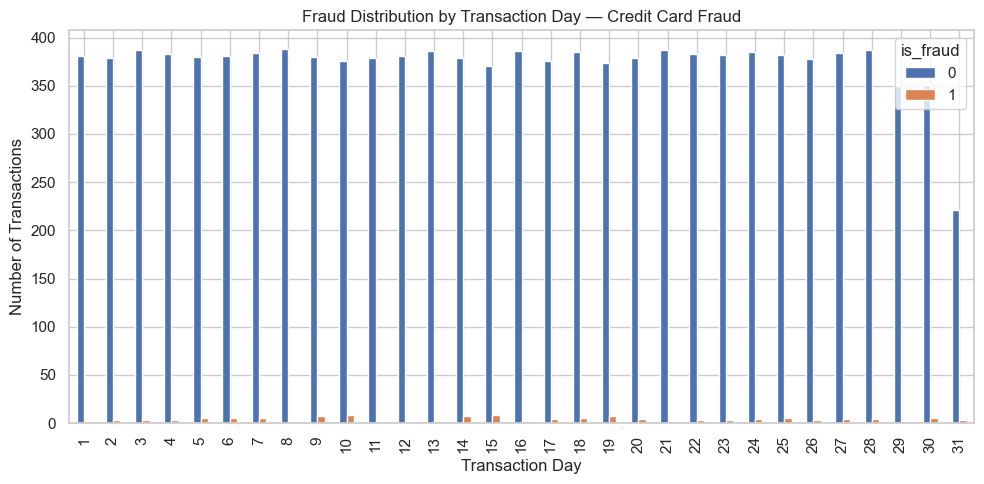

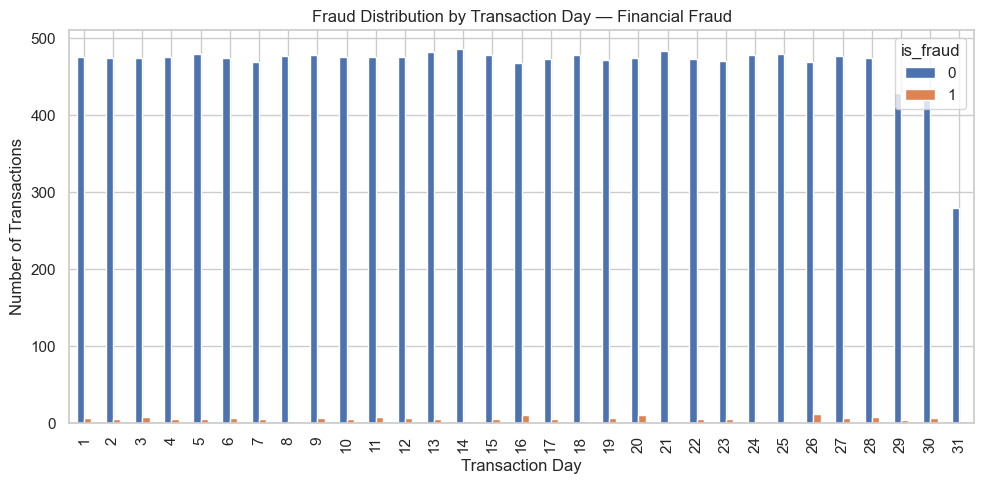

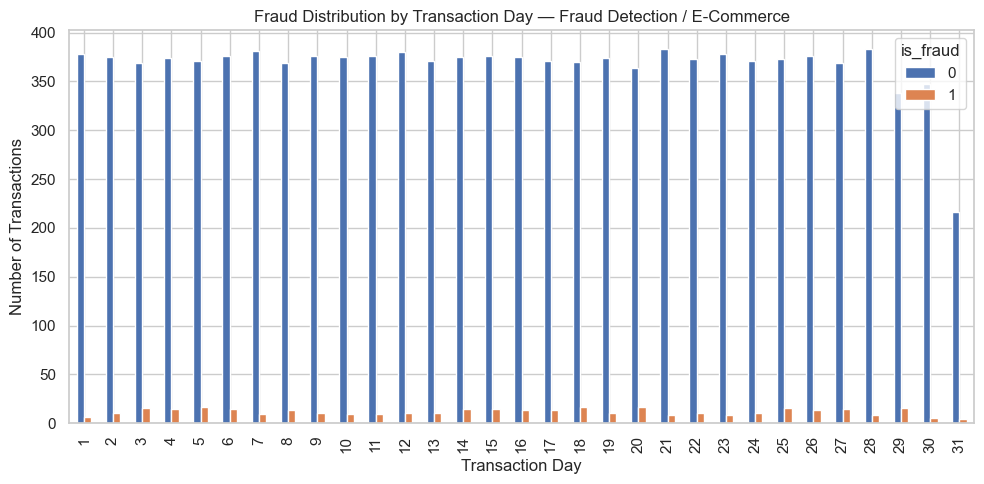

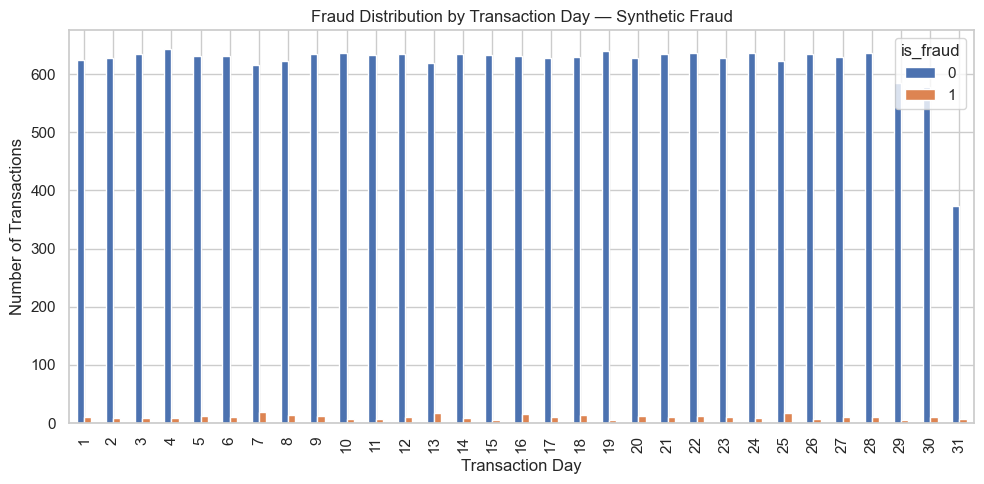

In [23]:
for name, df in datasets.items():
    pd.crosstab(df["transaction_day"], df["is_fraud"]).plot(kind="bar", figsize=(10, 5))
    plt.title(f"Fraud Distribution by Transaction Day — {name}")
    plt.xlabel("Transaction Day")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

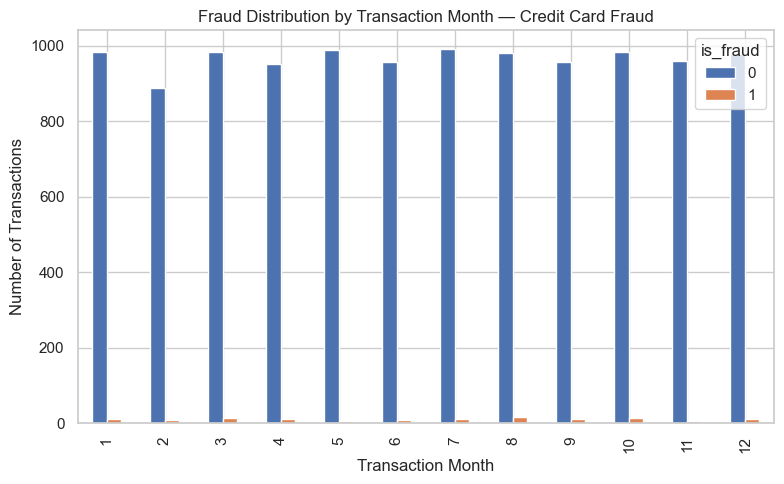

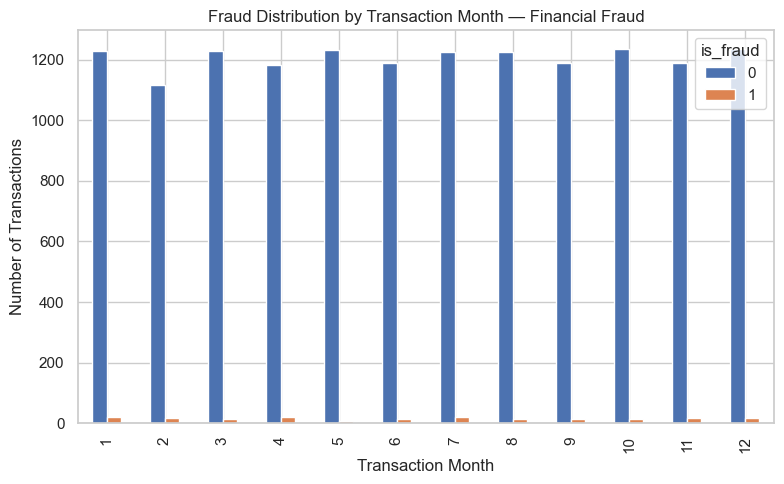

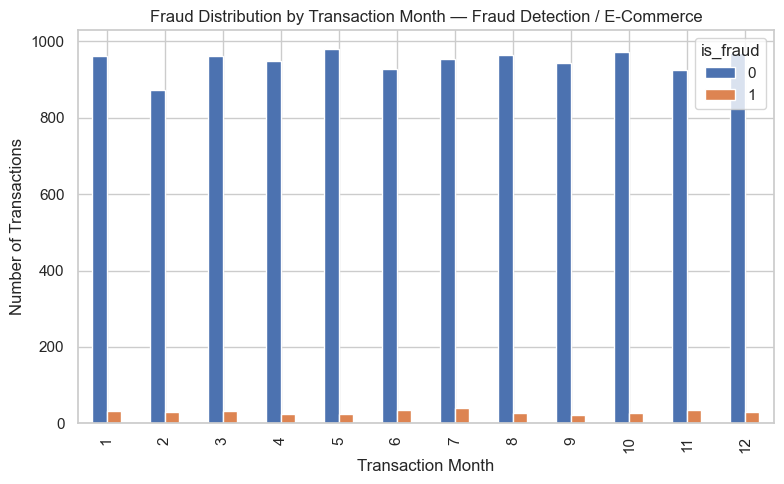

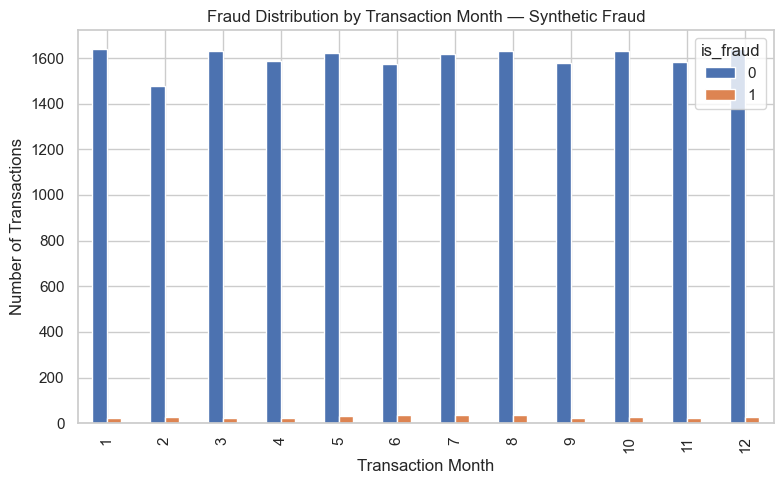

In [24]:
for name, df in datasets.items():
    pd.crosstab(df["transaction_month"], df["is_fraud"]).plot(kind="bar", figsize=(8, 5))
    plt.title(f"Fraud Distribution by Transaction Month — {name}")
    plt.xlabel("Transaction Month")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

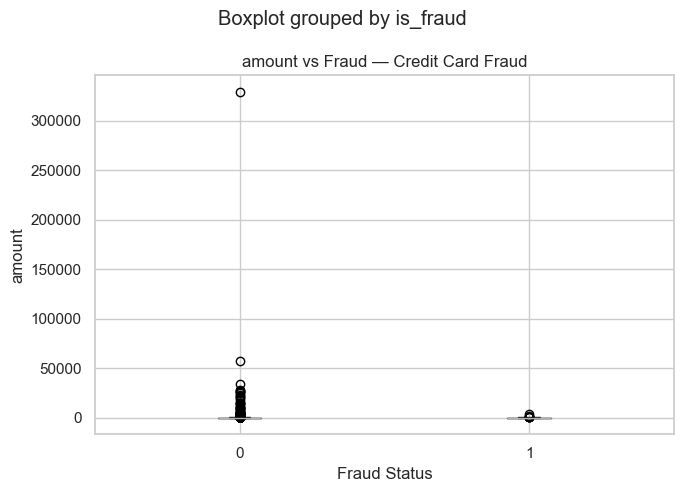

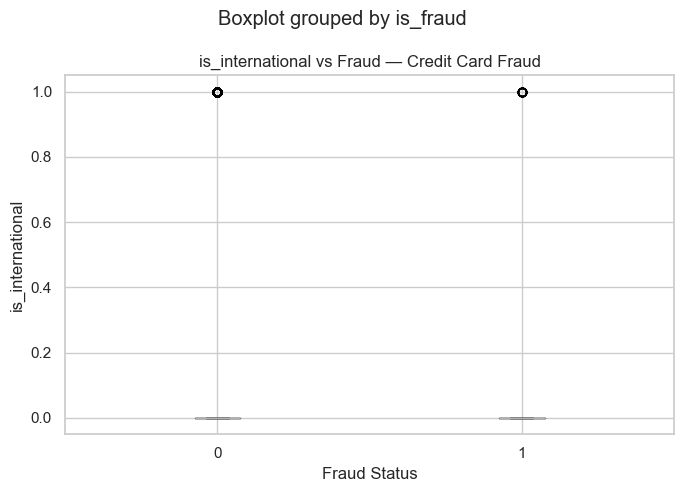

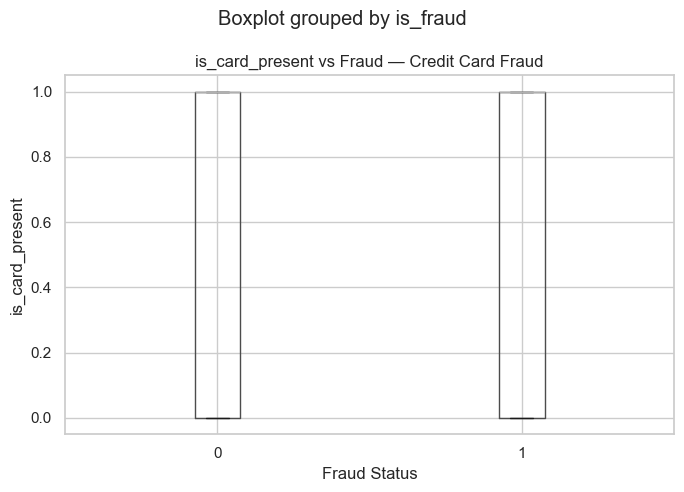

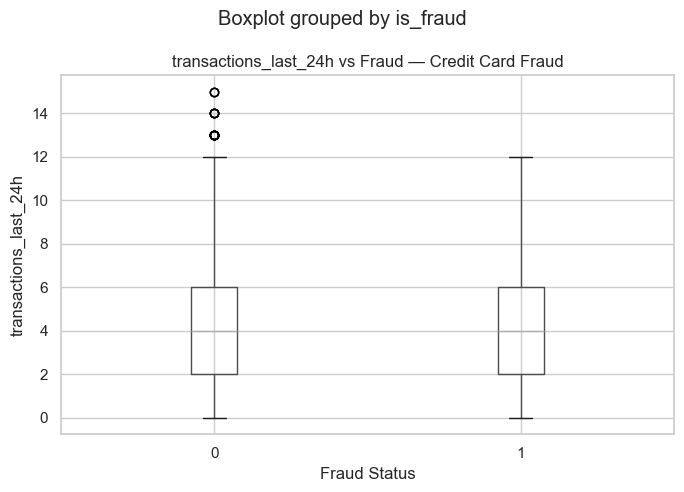

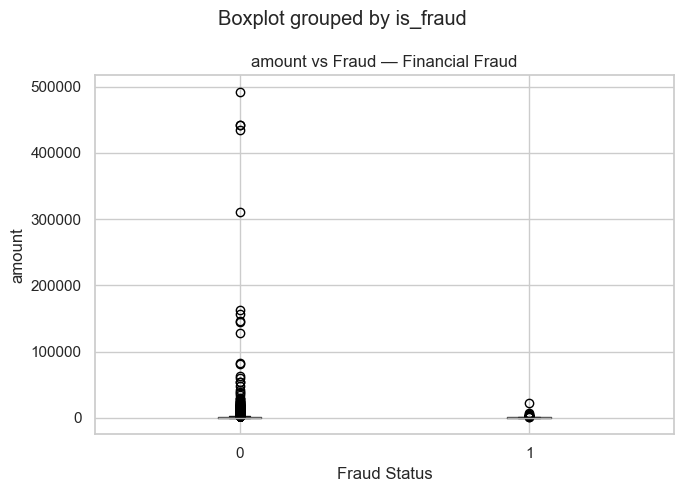

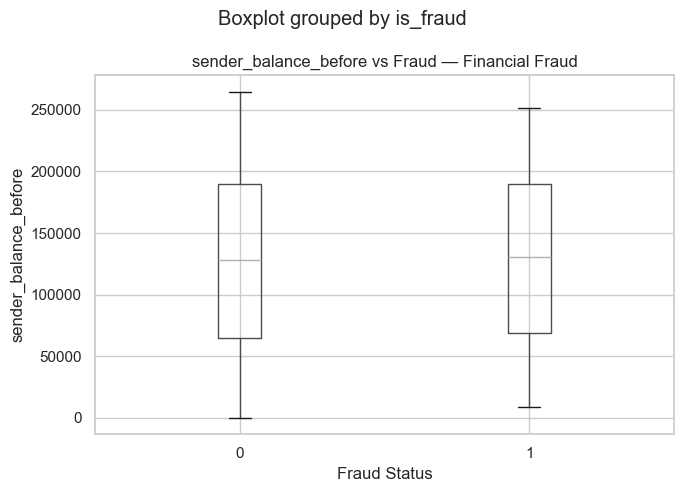

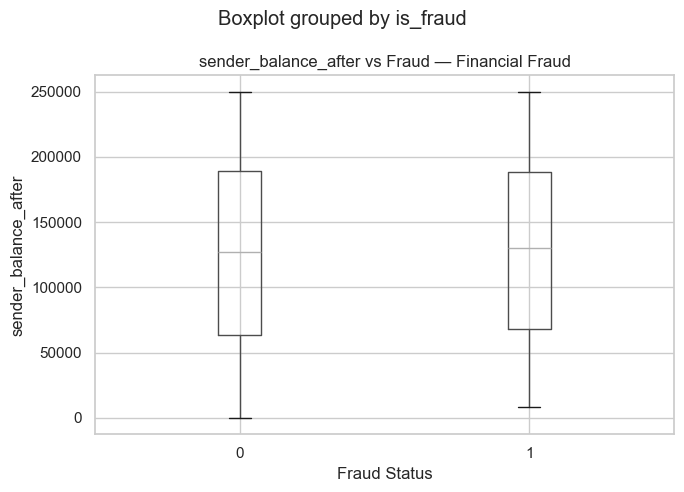

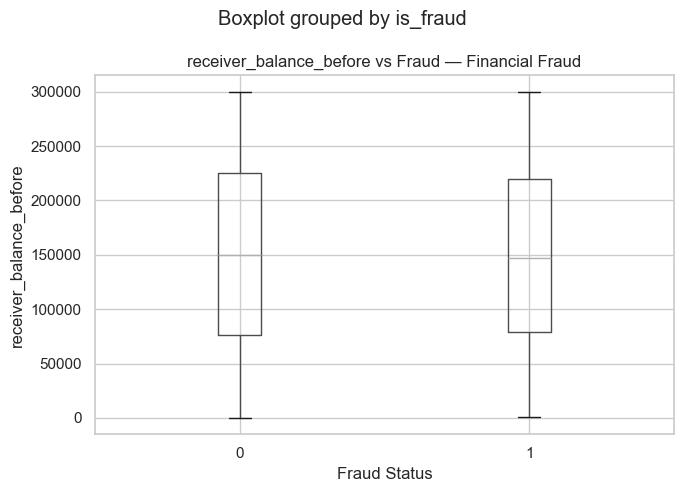

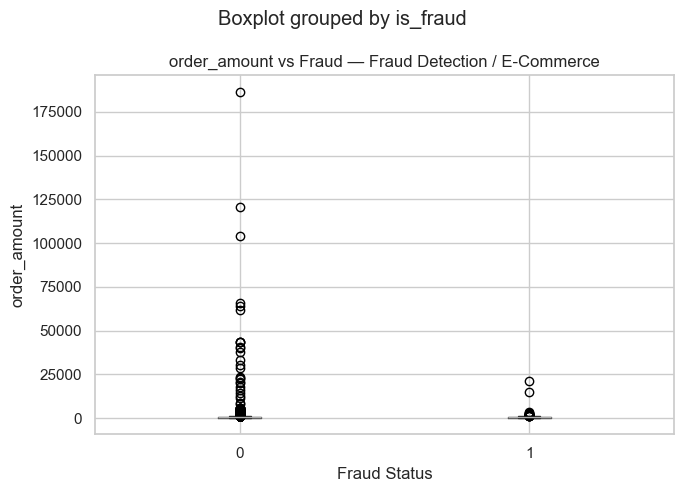

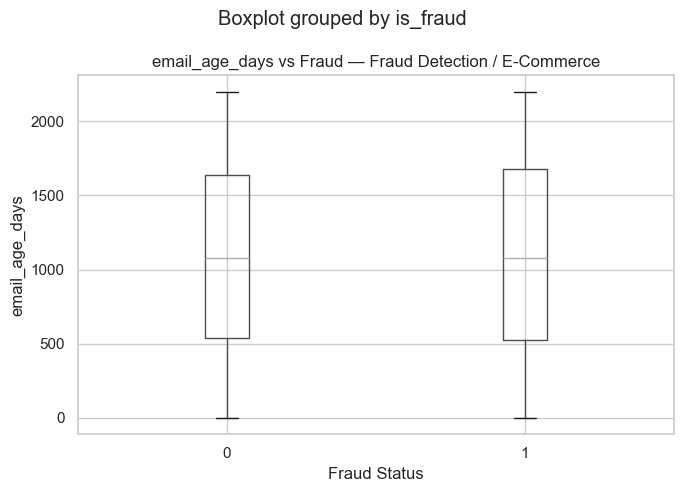

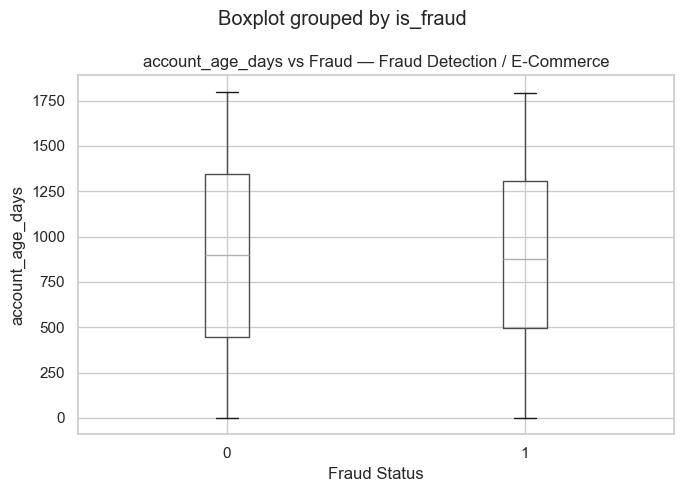

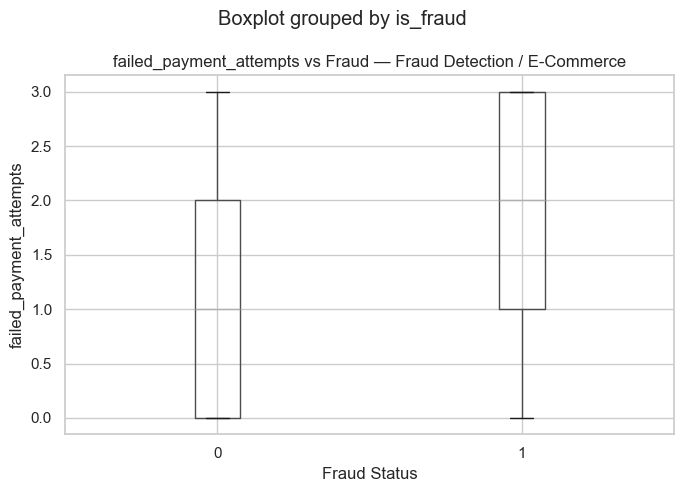

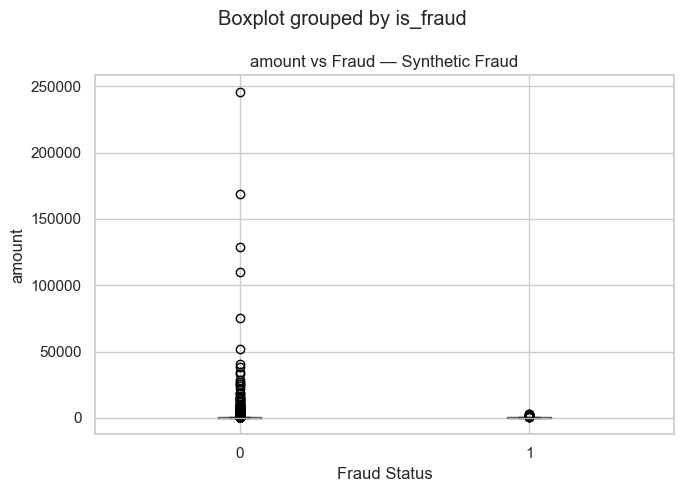

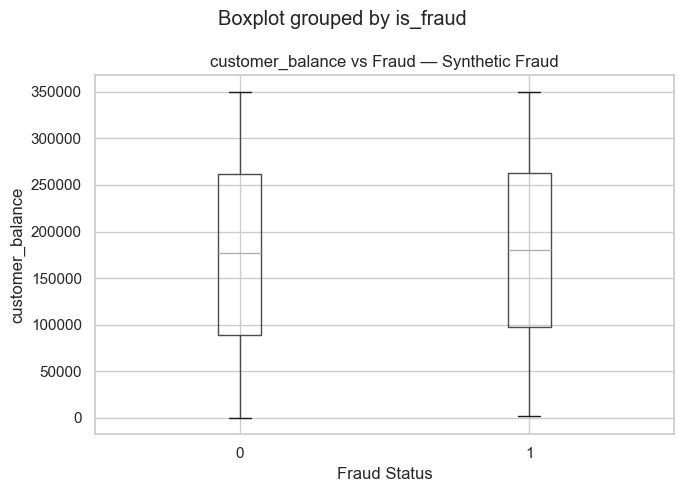

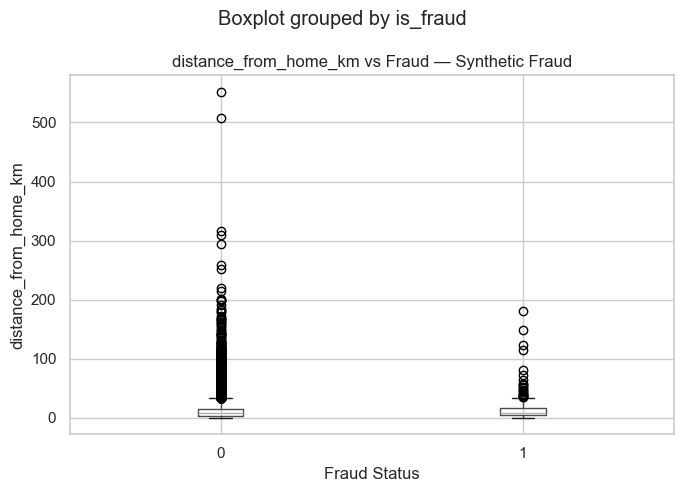

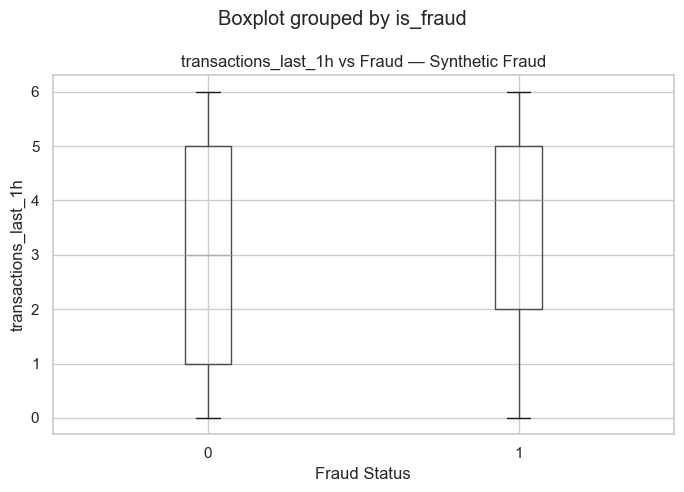

In [25]:
for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [
        c for c in numeric_cols
        if c not in ["is_fraud", "transaction_hour", "transaction_day", "transaction_month"]
        and "id" not in c.lower()
    ][:4]

    for col in numeric_cols:
        plt.figure(figsize=(7, 5))
        df.boxplot(column=col, by="is_fraud", ax=plt.gca())
        plt.title(f"{col} vs Fraud — {name}")
        plt.xlabel("Fraud Status")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

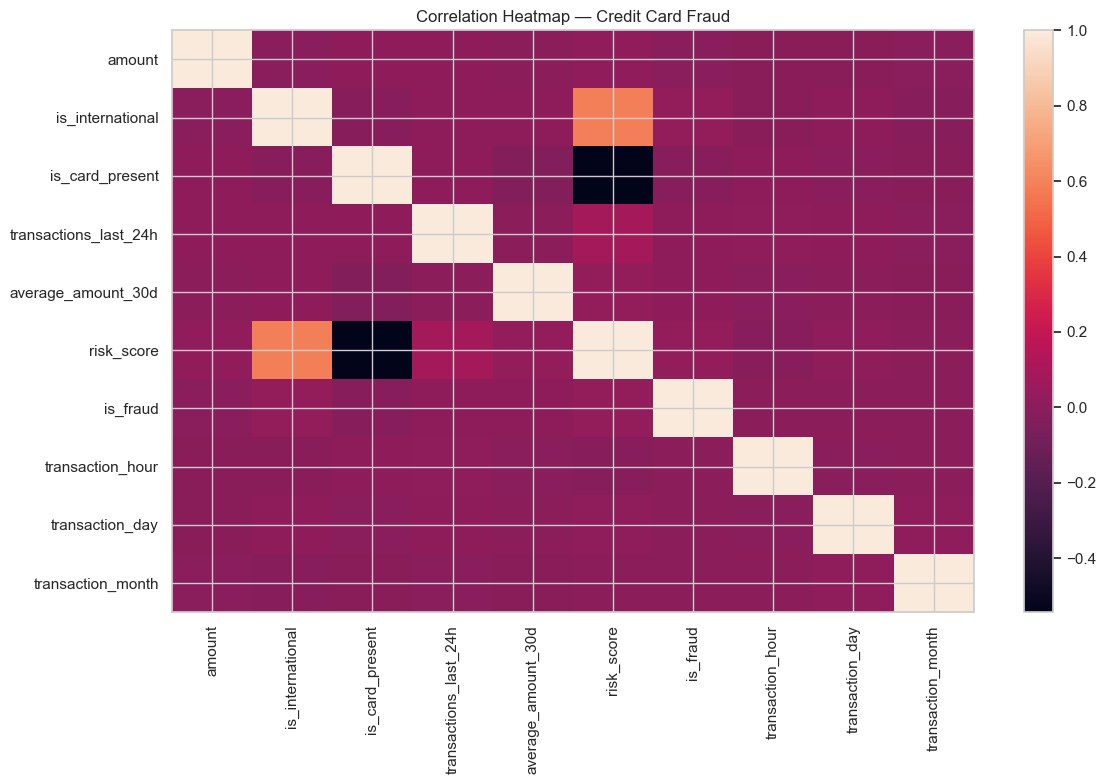

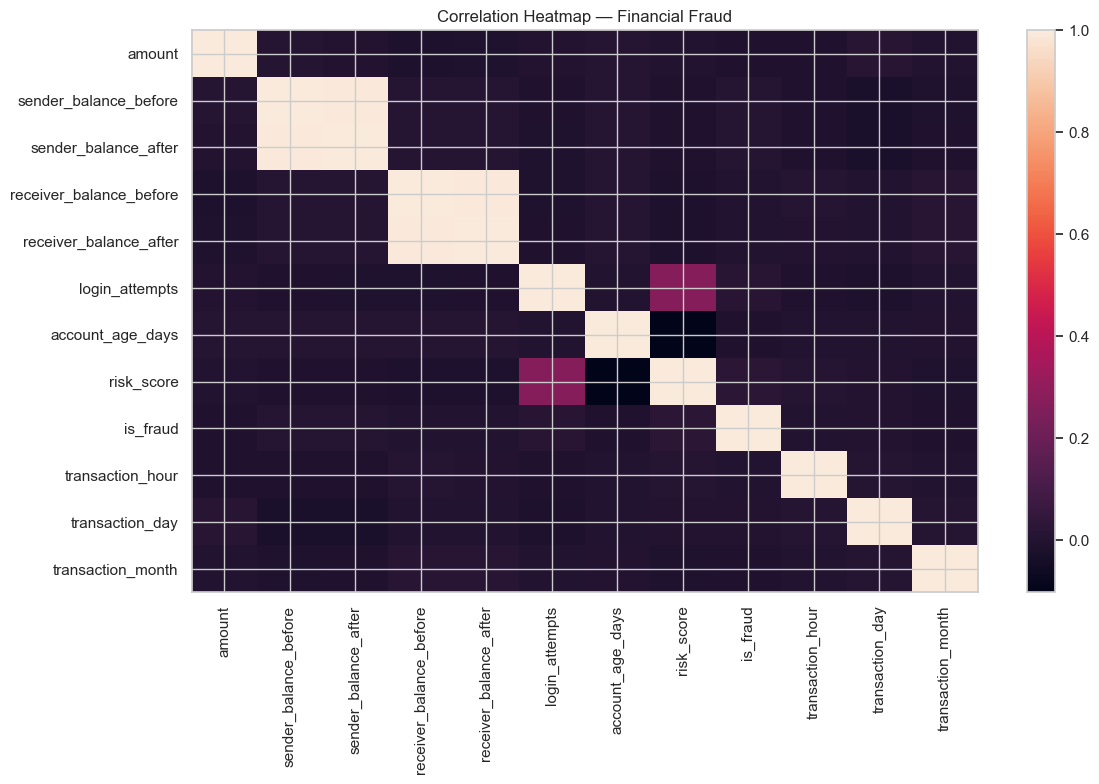

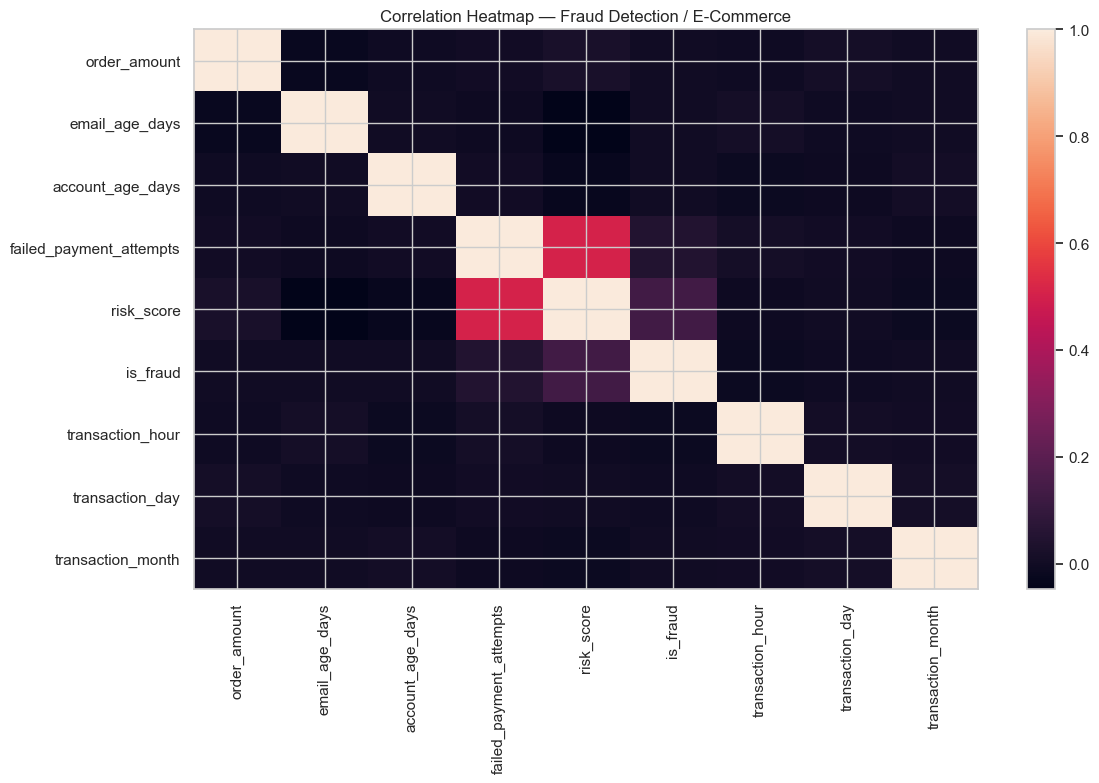

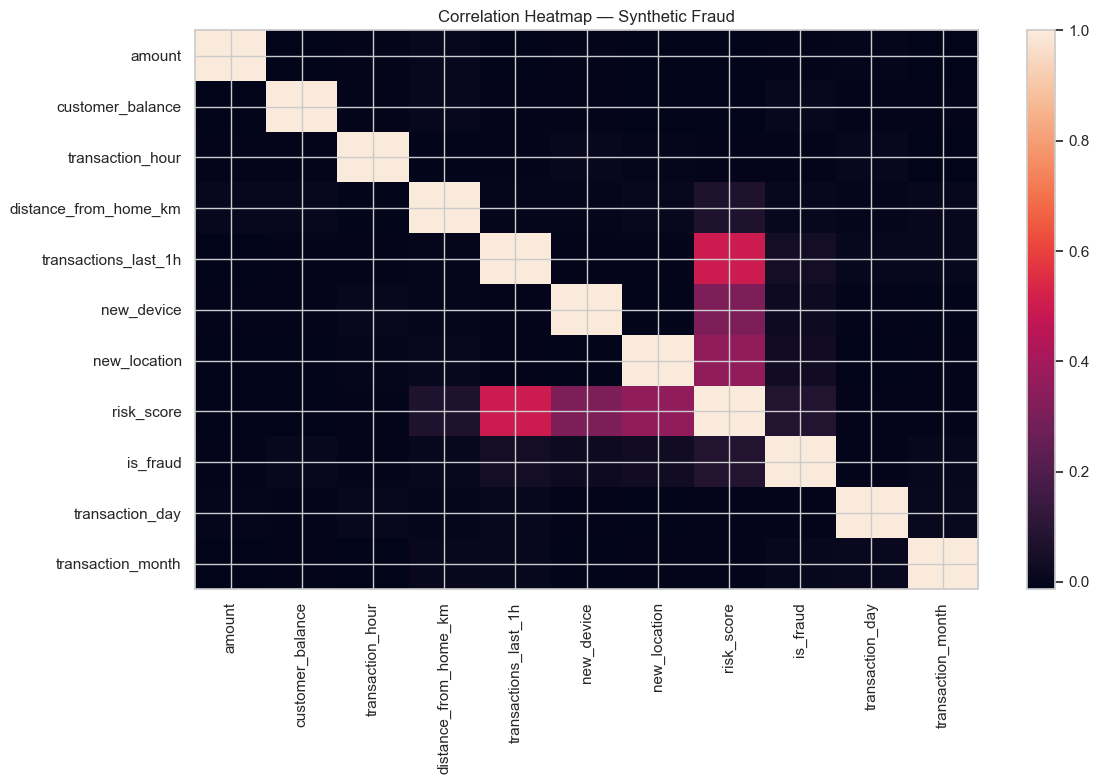

In [26]:
for name, df in datasets.items():
    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.shape[1] >= 2:
        plt.figure(figsize=(12, 8))
        plt.imshow(numeric_df.corr(), aspect="auto"); plt.colorbar(); plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90); plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
        plt.title(f"Correlation Heatmap — {name}")
        plt.tight_layout()
        plt.show()

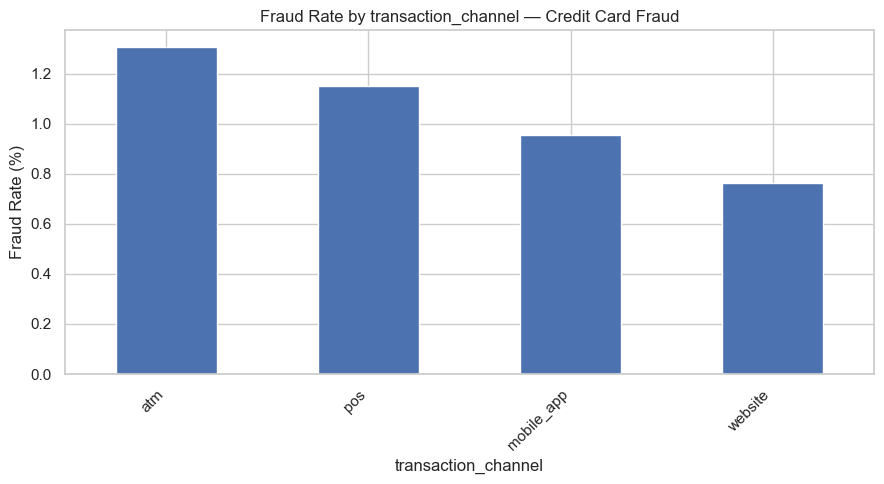

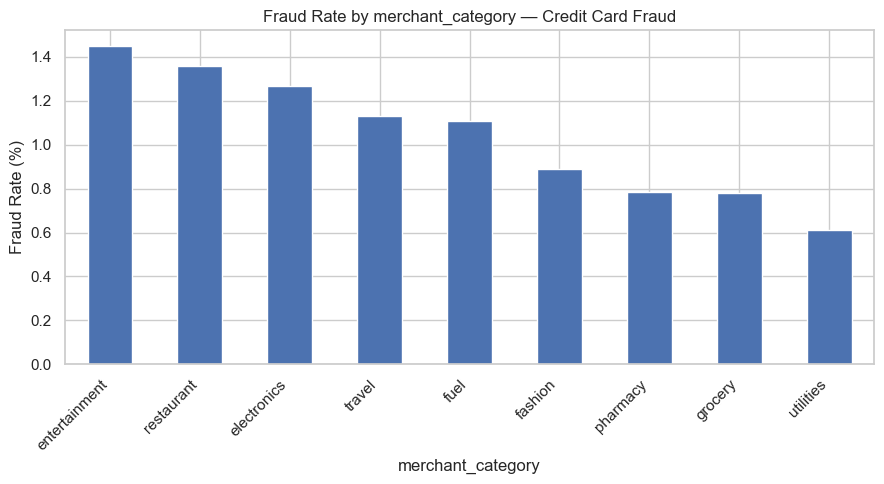

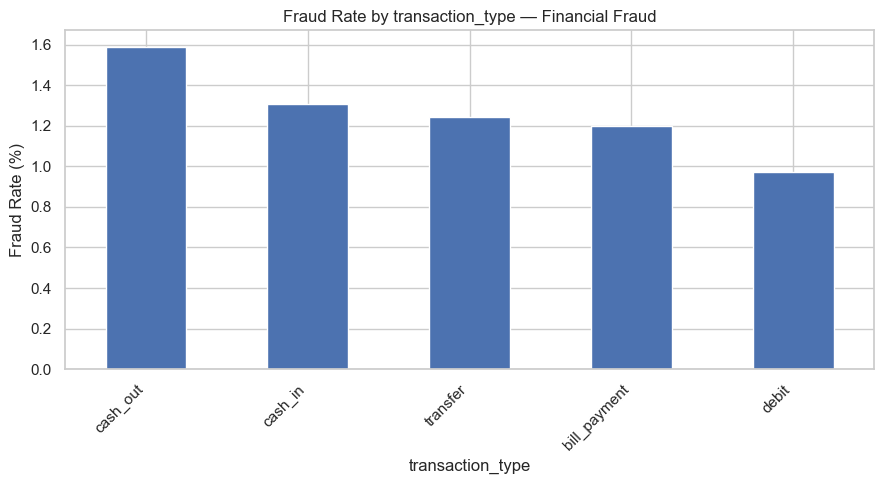

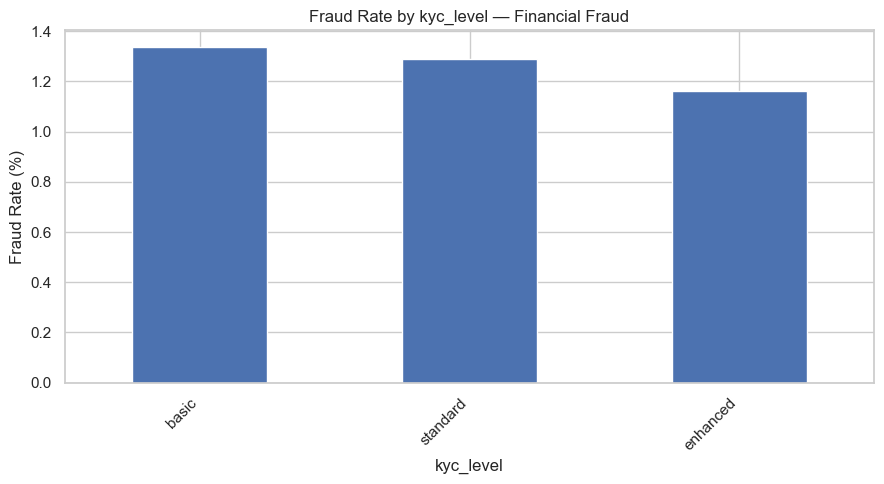

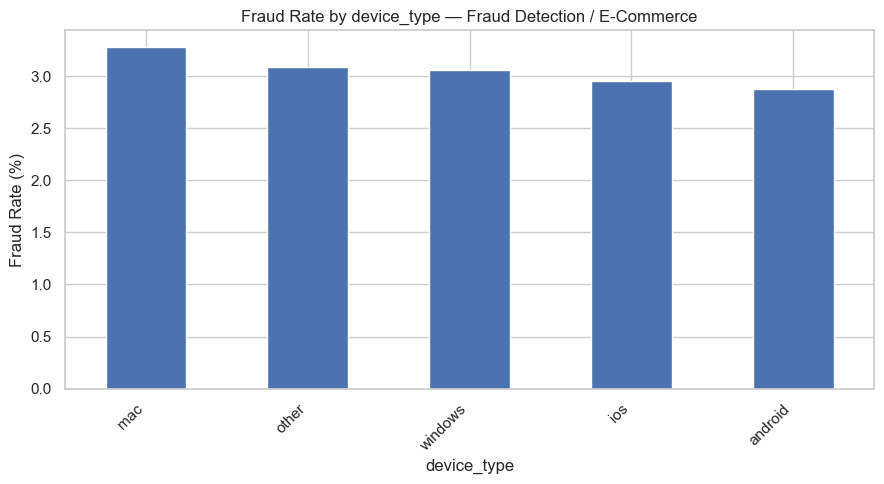

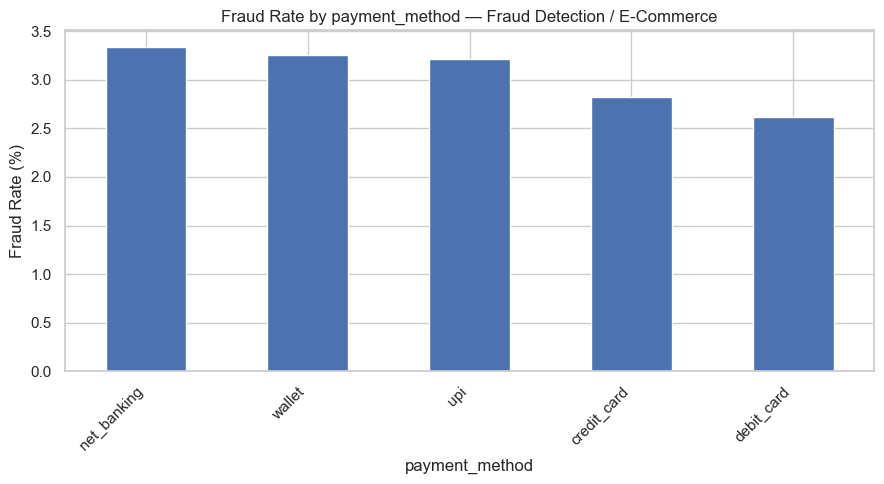

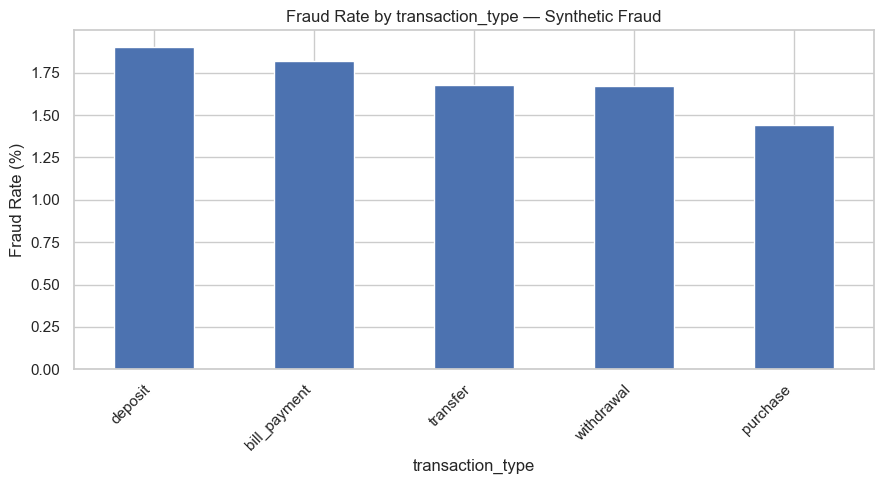

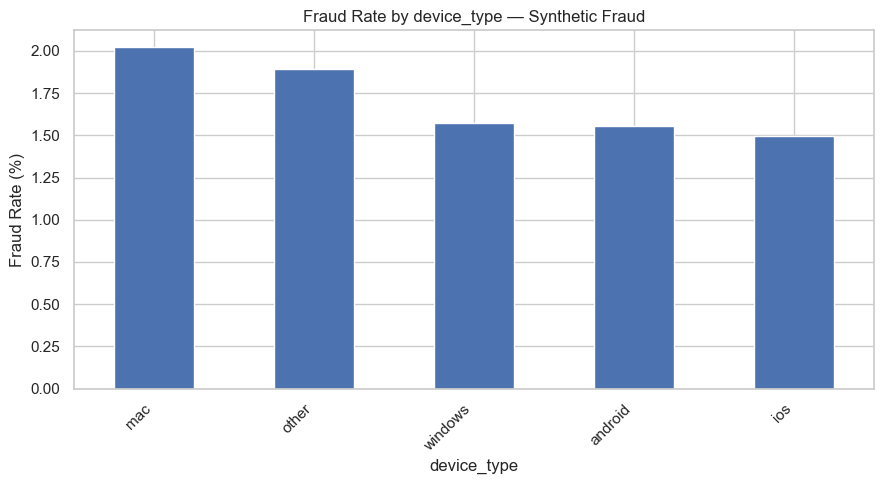

In [27]:
for name, df in datasets.items():
    available = [c for c in preferred_categoricals if c in df.columns][:2]

    for col in available:
        rate = df.groupby(col)["is_fraud"].mean().mul(100).sort_values(ascending=False).head(10)

        plt.figure(figsize=(9, 5))
        rate.plot(kind="bar")
        plt.title(f"Fraud Rate by {col} — {name}")
        plt.xlabel(col)
        plt.ylabel("Fraud Rate (%)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

In [3]:
credit_card_df = pd.read_csv("credit_card_fraud_cleaned.csv")
financial_df = pd.read_csv("financial_fraud_cleaned.csv")
fraud_detection_df = pd.read_csv("fraud_detection_cleaned.csv")
synthetic_df = pd.read_csv("synthetic_fraud_cleaned.csv")

In [4]:
print("Credit Card Fraud:", credit_card_df.shape)
print("Financial Fraud:", financial_df.shape)
print("Fraud Detection:", fraud_detection_df.shape)
print("Synthetic Fraud:", synthetic_df.shape)

Credit Card Fraud: (11726, 18)
Financial Fraud: (14654, 20)
Fraud Detection: (11741, 19)
Synthetic Fraud: (19540, 17)


In [5]:
credit_card_df["dataset_source"] = "Credit Card Fraud"
financial_df["dataset_source"] = "Financial Fraud"
fraud_detection_df["dataset_source"] = "Fraud Detection"
synthetic_df["dataset_source"] = "Synthetic Fraud"

In [6]:
fraud_detection_df.rename(columns={
    "order_id": "transaction_id",
    "order_date": "transaction_date",
    "order_amount": "amount"
}, inplace=True)

In [7]:
merged_df = pd.concat(
    [
        credit_card_df,
        financial_df,
        fraud_detection_df,
        synthetic_df
    ],
    ignore_index=True,
    sort=False
)

In [8]:
print("Total rows and columns:", merged_df.shape)

merged_df.head()

Total rows and columns: (57661, 45)


,transaction_id,transaction_date,customer_id,card_type,amount,merchant_category,merchant_country,transaction_channel,device_type,is_international,...,email_age_days,ip_risk_level,failed_payment_attempts,delivery_speed,customer_balance,location,distance_from_home_km,transactions_last_1h,new_device,new_location
0,CC00011340,2025-07-15 19:54:24,C002995,visa,55.82,travel,uae,website,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CC00007384,2025-07-08 14:57:48,C003084,mastercard,85.33,travel,uae,atm,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CC00002213,2025-05-02 20:09:53,C003082,amex,76.06,entertainment,united states,website,other,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CC00009658,2025-01-12 15:39:05,C002467,rupay,72.56,travel,united states,website,windows,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CC00009328,2025-07-31 05:04:38,C001852,rupay,257.07,fuel,uae,pos,android,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
merged_df.isnull().sum()

transaction_id                 0
transaction_date               0
customer_id                14654
card_type                  45935
amount                         0
merchant_category          45935
merchant_country           45935
transaction_channel        45935
device_type                14654
is_international           45935
is_card_present            45935
transactions_last_24h      45935
average_amount_30d         45935
risk_score                     0
is_fraud                       0
transaction_hour               0
transaction_day                0
transaction_month              0
dataset_source                 0
sender_account_id          43007
receiver_account_id        43007
transaction_type           23467
sender_balance_before      43007
sender_balance_after       43007
receiver_balance_before    43007
receiver_balance_after     43007
customer_age_group         43007
customer_city              43007
kyc_level                  43007
login_attempts             43007
account_ag

In [10]:
print("Duplicate rows:", merged_df.duplicated().sum())

Duplicate rows: 0


In [11]:
merged_df.to_csv("merged_fraud_dataset.csv", index=False)

print("Merged dataset saved successfully!")

Merged dataset saved successfully!
